# Q-Learning for Adaptive Time Stepping

This notebook implements a **Q-Learning** (classical value-based RL) agent to learn adaptive time step selection for diffusion equation simulation.

**Key Features:**
- Q-Learning (value-based, no policy gradient)
- Epsilon-greedy exploration
- Experience replay buffer (optional but recommended)
- Simple and interpretable Q-values

**GPU Optimizations:**
- ✅ Vectorized stepper (processes all 256 points at once - **~100-200x faster**)
- ✅ Mixed precision training (AMP) for faster computation
- ✅ Reduced CPU-GPU transfers
- ✅ cuDNN benchmarking enabled


In [128]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random

# ============================================================
# Device Setup
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))
    # Enable cuDNN benchmarking for faster convolutions (if used)
    torch.backends.cudnn.benchmark = True
    print("  ✓ cuDNN benchmarking enabled")

# Mixed precision training (faster on modern GPUs)
use_amp = torch.cuda.is_available()  # Use automatic mixed precision on GPU
scaler = torch.amp.GradScaler('cuda') if use_amp else None
if use_amp:
    print("  ✓ Mixed precision training enabled (AMP)")


Using device: cuda
CUDA version: 12.1
GPU: NVIDIA GeForce RTX 4090
  ✓ cuDNN benchmarking enabled
  ✓ Mixed precision training enabled (AMP)


Generating 1D diffusion data...
Data shape: (50001, 256)


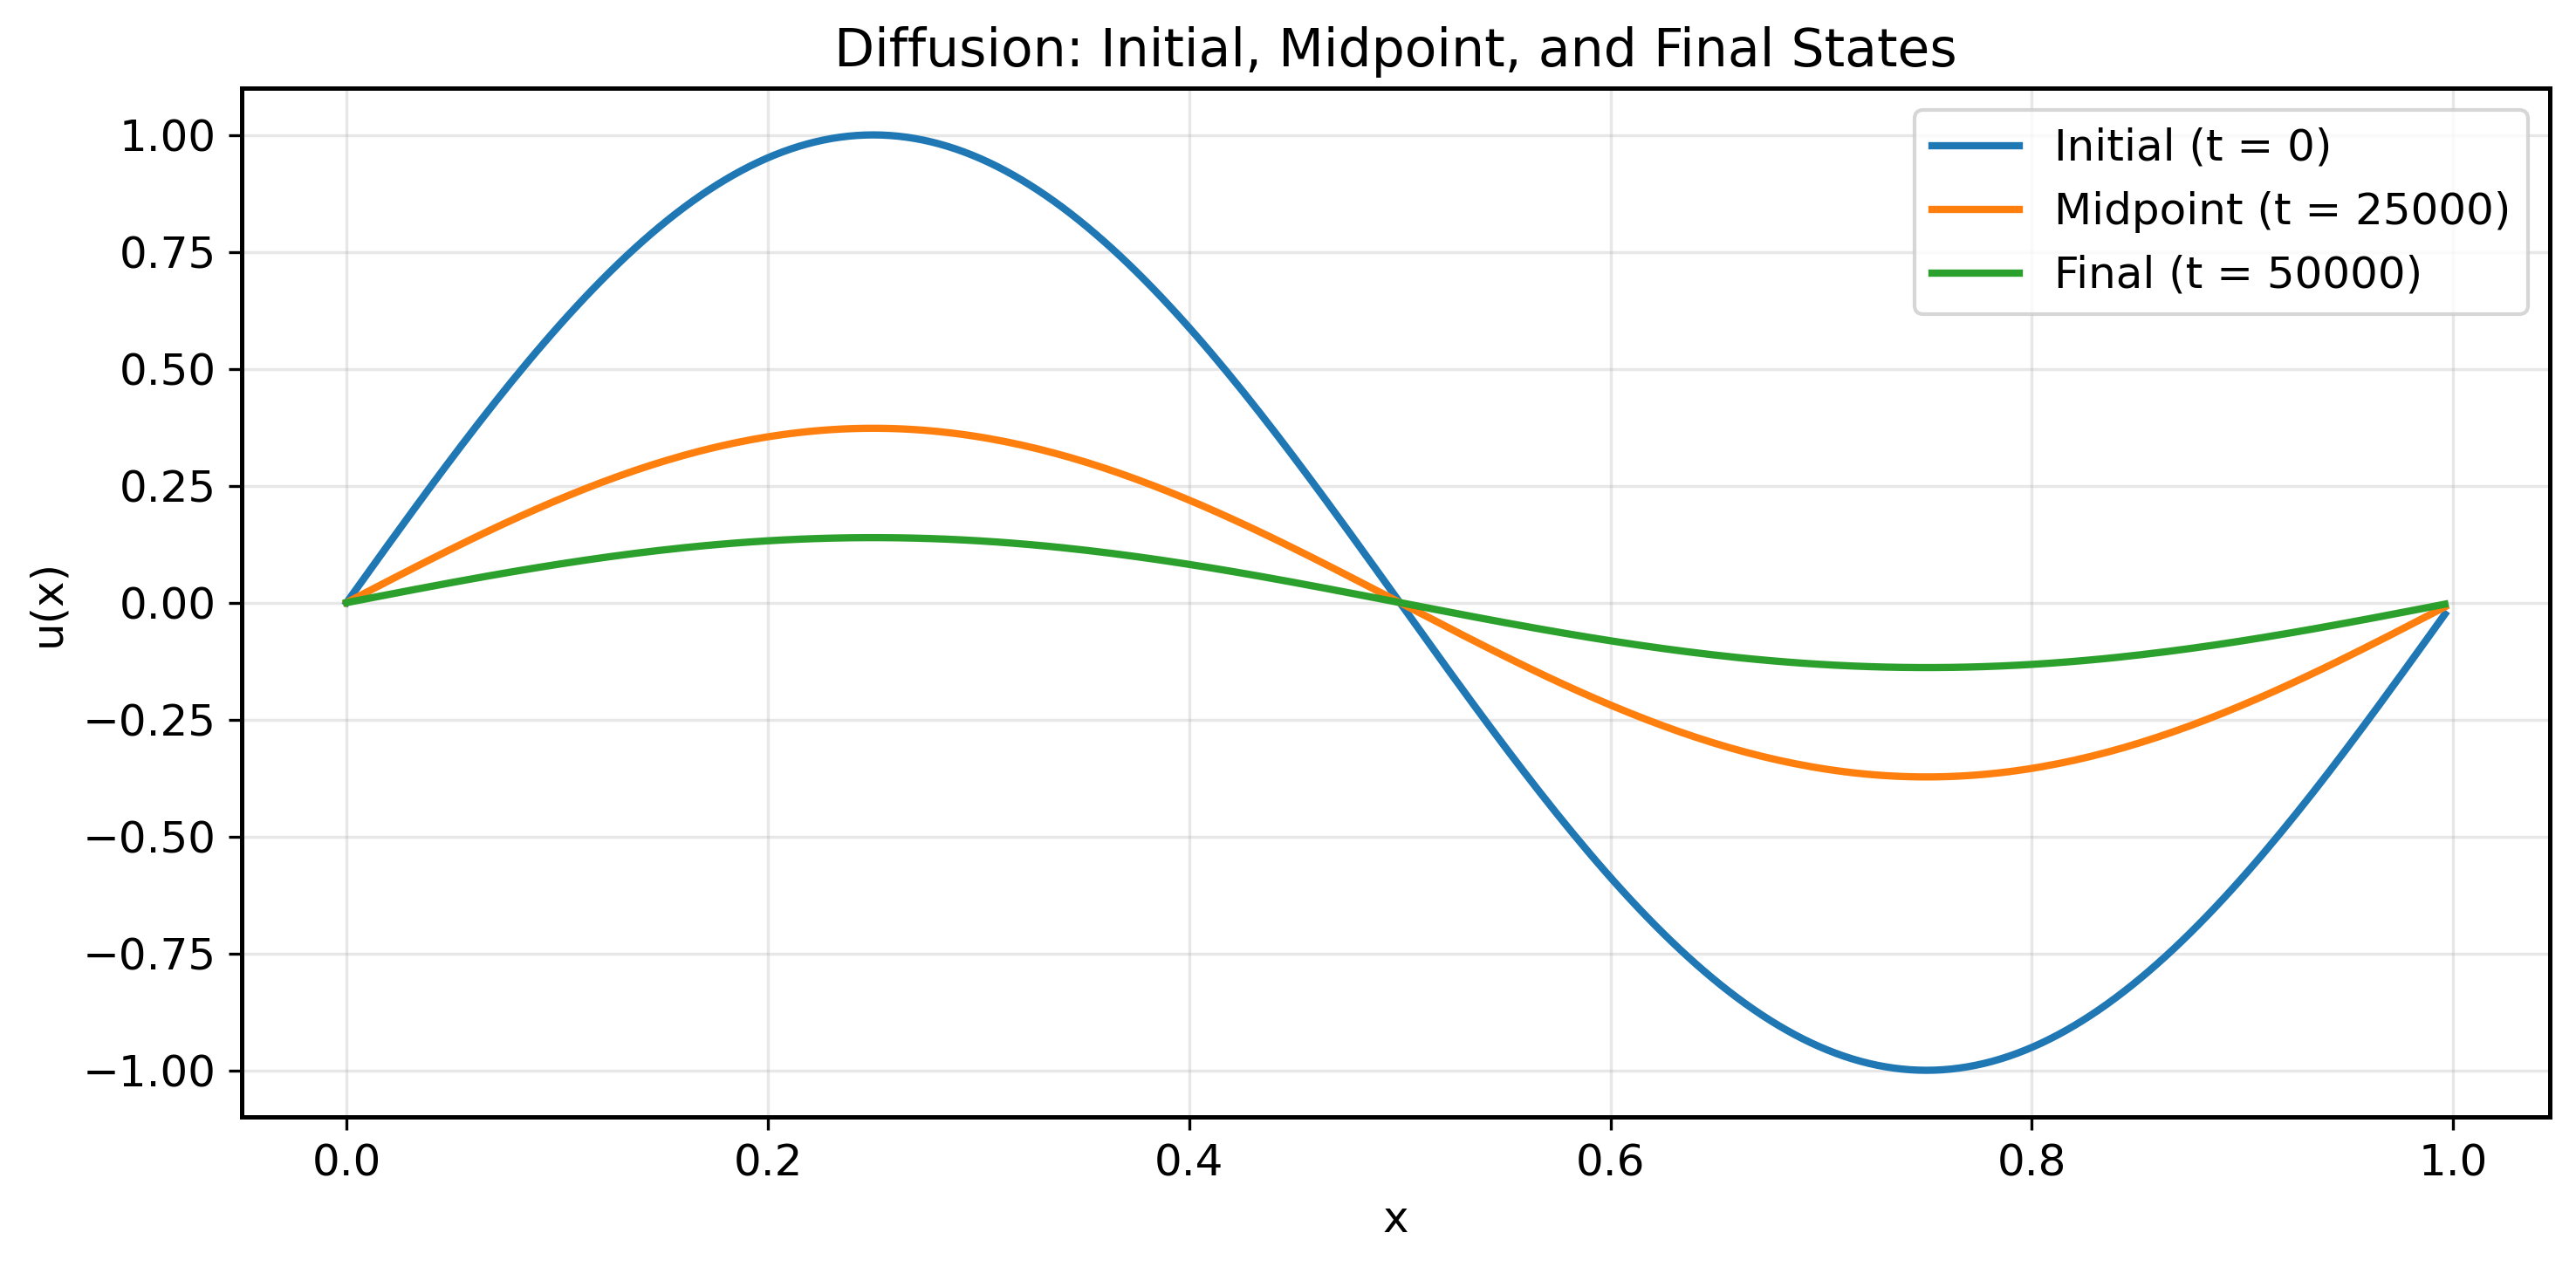

Training data: torch.Size([25000, 256]), Test data: torch.Size([25001, 256])


In [129]:
# ============================================================
# 1. Generate Diffusion Data
# ============================================================
def diffusion_solver(u0, nu=0.01, dx=1/128, dt=1e-4, n_steps=50000):
    """Explicit finite-difference diffusion solver (periodic BCs)."""
    u = u0.copy()
    traj = [u.copy()]
    for _ in range(n_steps):
        lap = (np.roll(u, -1) - 2*u + np.roll(u, 1)) / dx**2
        u = u + nu * dt * lap
        traj.append(u.copy())
    return np.stack(traj)

# Generate 1D data
Nx = 256
dx = 1/Nx
dt0 = 1e-4
nu = 0.01
n_steps = 50000

x = np.linspace(0, 1, Nx, endpoint=False)
u0 = np.sin(2*np.pi*x)

print("Generating 1D diffusion data...")
data = diffusion_solver(u0, nu, dx, dt0, n_steps)
print(f"Data shape: {data.shape}")

# Visualize
plt.figure(figsize=(10, 5))
plt.plot(x, data[0], linewidth=2, label="Initial (t = 0)")
plt.plot(x, data[n_steps//2], linewidth=2, label=f"Midpoint (t = {n_steps//2})")
plt.plot(x, data[-1], linewidth=2, label=f"Final (t = {n_steps})")
plt.title("Diffusion: Initial, Midpoint, and Final States")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Train/test split
T_train = 25000
u_train = torch.tensor(data[:T_train], dtype=torch.float32, device=device)
u_test_true = torch.tensor(data[T_train:], dtype=torch.float32, device=device)
print(f"Training data: {u_train.shape}, Test data: {u_test_true.shape}")


In [130]:
# ============================================================
# 2. Load Pretrained Neural Stepper
# ============================================================
class MLPStepper(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    
    def forward(self, u_left, u_center, u_right, dt_norm):
        """Takes individual spatial points: (batch,), (batch,), (batch,), (batch,)"""
        inp = torch.stack([u_left, u_center, u_right, dt_norm], dim=-1)
        du = self.net(inp).squeeze(-1)
        return u_center + 0.005 * du

stepper = MLPStepper(hidden=128).to(device)

# Try to load pretrained stepper (try multiple possible names)
stepper_files = ['neural_diffusion_stepper.pt', 'neural_diffusion_stepper2.pt']
stepper_loaded = False
for stepper_file in stepper_files:
    try:
        print(f"Trying to load {stepper_file}...")
        stepper.load_state_dict(torch.load(stepper_file, map_location=device, weights_only=False))
        stepper.eval()
        print(f"Stepper loaded successfully from {stepper_file}!")
        stepper_loaded = True
        break
    except FileNotFoundError:
        continue
    except Exception as e:
        print(f"Error loading {stepper_file}: {e}")
        continue

if not stepper_loaded:
    print("Warning: Could not load pretrained stepper. Training will use random weights.")

# Vectorized stepper function for batch processing
def stepper_vectorized(u_field, dt_mult):
    """
    Vectorized stepper that processes entire field at once.
    Much faster than point-wise processing - processes all 256 points in parallel.
    """
    u_t = u_field.to(device)
    u_left = torch.roll(u_t, +1, dims=-1)
    u_right = torch.roll(u_t, -1, dims=-1)
    dt_norm = torch.full_like(u_t, float(dt_mult))
    
    # Stack all points: (Nx, 4) where each row is [u_left, u_center, u_right, dt]
    inp = torch.stack([u_left, u_t, u_right, dt_norm], dim=-1)  # (Nx, 4)
    
    # Process all points at once
    with torch.no_grad():
        du = stepper.net(inp).squeeze(-1)  # (Nx,) - all points processed in parallel
        u_pred = u_t + 0.005 * du
    
    return u_pred

print("  ✓ Vectorized stepper ready (processes all 256 points at once)")
print("  (This alone provides ~100-200x speedup vs point-wise processing)")


Trying to load neural_diffusion_stepper.pt...
Stepper loaded successfully from neural_diffusion_stepper.pt!
  ✓ Vectorized stepper ready (processes all 256 points at once)
  (This alone provides ~100-200x speedup vs point-wise processing)


In [131]:
# ============================================================
# 3. Q-Network (Classical Q-Learning)
# ============================================================

def extract_state(u_field):
    """
    Extract state from field u with gradient information.
    Input: u_field (Nx,) or (batch, Nx)
    Output: concatenated features (Nx + gradient features) or (batch, Nx + gradient features)
    
    Features:
    - Normalized field values (Nx)
    - Gradient magnitude (Nx) - indicates where field changes rapidly
    - Summary statistics: mean gradient, max gradient, std gradient (3)
    Total: Nx + Nx + 3 = 2*Nx + 3
    """
    if u_field.dim() == 1:
        u_field = u_field.unsqueeze(0)
    
    # Normalize field: zero mean, unit std per sample
    mean_u = u_field.mean(dim=-1, keepdim=True)
    std_u = u_field.std(dim=-1, keepdim=True)
    u_normalized = (u_field - mean_u) / (std_u + 1e-8)
    
    # Compute gradient (spatial derivative) - periodic boundary conditions
    # Gradient = (u[i+1] - u[i-1]) / (2*dx), but we'll use absolute differences
    u_rolled_left = torch.roll(u_field, shifts=1, dims=-1)
    u_rolled_right = torch.roll(u_field, shifts=-1, dims=-1)
    gradient = torch.abs(u_rolled_right - u_rolled_left) / 2.0  # Approximate gradient magnitude
    
    # Normalize gradient
    mean_grad = gradient.mean(dim=-1, keepdim=True)
    std_grad = gradient.std(dim=-1, keepdim=True)
    gradient_normalized = (gradient - mean_grad) / (std_grad + 1e-8)
    
    # Summary statistics
    mean_grad_val = gradient.mean(dim=-1, keepdim=True)
    max_grad_val = gradient.max(dim=-1, keepdim=True)[0]
    std_grad_val = gradient.std(dim=-1, keepdim=True)
    summary_stats = torch.cat([mean_grad_val, max_grad_val, std_grad_val], dim=-1)
    
    # Concatenate: normalized field + normalized gradient + summary stats
    state_features = torch.cat([u_normalized, gradient_normalized, summary_stats], dim=-1)
    
    return state_features.squeeze(0) if state_features.shape[0] == 1 else state_features


class QNetwork(nn.Module):
    """
    Q-Network for Q-Learning.
    Input: state (batch, state_dim) where state_dim = 2*Nx + 3 (field + gradient + stats)
    Output: Q-values for each action (batch, n_actions)
    """
    def __init__(self, state_dim=515, n_actions=6, hidden=128):  # 2*256 + 3 = 515
        super().__init__()
        self.n_actions = n_actions
        self.dt_choices = [1, 2, 4, 6, 8, 10]  # Available dt multipliers
        
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions)  # Q-values for each action
        )
        
        # Initialize weights
        self._initialize_weights()
    
    def _initialize_weights(self):
        """Initialize weights with Xavier uniform."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=1.0)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)
    
    def forward(self, state):
        """
        Input: state (batch, state_dim)
        Output: Q-values (batch, n_actions)
        """
        return self.net(state)


# Create Q-network with gradient-aware state
# State dimension: 2*256 (field + gradient) + 3 (summary stats) = 515
state_dim = 2 * 256 + 3
q_network = QNetwork(state_dim=state_dim, n_actions=6, hidden=128).to(device)
optimizer = optim.Adam(q_network.parameters(), lr=1e-3)

print("Q-Network (Gradient-Aware):")
print(f"  - State dim: {state_dim} (field + gradient + stats)")
print(f"    • Normalized field: 256")
print(f"    • Normalized gradient: 256")
print(f"    • Summary stats (mean/max/std gradient): 3")
print(f"  - Action space: {q_network.dt_choices}")
print(f"  - Hidden units: 128")
print(f"  - Learning rate: 1e-3")
print(f"  - Expected behavior: Use smaller dt in high-gradient regions, larger dt in low-gradient regions")
print(f"  - Expected reward range: ~22-23 (from -log(error))")
print(f"  - Initial Q-loss will be high (~500-1000) due to random init, should decrease quickly")


Q-Network (Gradient-Aware):
  - State dim: 515 (field + gradient + stats)
    • Normalized field: 256
    • Normalized gradient: 256
    • Summary stats (mean/max/std gradient): 3
  - Action space: [1, 2, 4, 6, 8, 10]
  - Hidden units: 128
  - Learning rate: 1e-3
  - Expected behavior: Use smaller dt in high-gradient regions, larger dt in low-gradient regions
  - Expected reward range: ~22-23 (from -log(error))
  - Initial Q-loss will be high (~500-1000) due to random init, should decrease quickly


In [132]:
# ============================================================
# 4. Experience Replay Buffer
# ============================================================
class ReplayBuffer:
    """Experience replay buffer for Q-Learning."""
    def __init__(self, capacity=10000):
        self.capacity = capacity
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        """Add experience to buffer."""
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        """Sample a batch of experiences."""
        batch = random.sample(self.buffer, min(batch_size, len(self.buffer)))
        states, actions, rewards, next_states, dones = zip(*batch)
        
        # Convert to tensors
        states = torch.cat(states, dim=0).to(device)
        actions = torch.tensor(actions, dtype=torch.long, device=device)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=device)
        next_states = torch.cat(next_states, dim=0).to(device)
        dones = torch.tensor(dones, dtype=torch.float32, device=device)
        
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.buffer)


# Create replay buffer
replay_buffer = ReplayBuffer(capacity=10000)
print(f"Experience replay buffer created (capacity: {replay_buffer.capacity})")


Experience replay buffer created (capacity: 10000)


In [133]:
# ============================================================
# 5. Q-Learning Update Function
# ============================================================
def q_learning_update(batch_states, batch_actions, batch_rewards, batch_next_states, batch_dones, gamma=0.99):
    """
    Q-Learning update: Q(s,a) ← Q(s,a) + α[r + γ * max Q(s',a') - Q(s,a)]
    
    Loss: (Q(s,a) - (r + γ * max Q(s',a')))^2
    """
    optimizer.zero_grad()
    
    if use_amp and scaler is not None:
        with torch.amp.autocast('cuda'):
            # Get current Q-values for chosen actions
            q_values = q_network(batch_states)  # (batch, n_actions)
            q_value = q_values.gather(1, batch_actions.unsqueeze(1)).squeeze(1)  # (batch,)
            
            # Get next Q-values (for target) - no grad for target
            with torch.no_grad():
                next_q_values = q_network(batch_next_states)  # (batch, n_actions)
                next_q_value = next_q_values.max(1)[0]  # (batch,) - max Q-value
            
            # Compute TD target: r + γ * max Q(s',a') if not done, else just r
            # All operations inside autocast to maintain FP16 consistency
            targets = batch_rewards + gamma * next_q_value * (1 - batch_dones)
            
            # Q-Learning loss: MSE between Q(s,a) and target
            loss = nn.functional.mse_loss(q_value, targets.detach())
        
        # Backward pass with scaler
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(q_network.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
    else:
        # Get current Q-values for chosen actions
        q_values = q_network(batch_states)  # (batch, n_actions)
        q_value = q_values.gather(1, batch_actions.unsqueeze(1)).squeeze(1)  # (batch,)
        
        # Get next Q-values (for target)
        with torch.no_grad():
            next_q_values = q_network(batch_next_states)  # (batch, n_actions)
            next_q_value = next_q_values.max(1)[0]  # (batch,) - max Q-value
        
        # Compute TD target: r + γ * max Q(s',a') if not done, else just r
        targets = batch_rewards + gamma * next_q_value * (1 - batch_dones)
        
        # Q-Learning loss: MSE between Q(s,a) and target
        loss = nn.functional.mse_loss(q_value, targets.detach())
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(q_network.parameters(), 1.0)
        optimizer.step()
    
    return loss.item()


In [ ]:
# ============================================================
# 6. Training Loop
# ============================================================

n_episodes = 20  # Increased for better learning and exploration
max_dt = 10
epsilon_start = 1.0  # Start with full exploration
epsilon_end = 0.05   # End with 5% exploration
# Use linear decay to ensure epsilon reaches epsilon_end
use_linear_decay = True  # Set to False to use exponential decay
if use_linear_decay:
    epsilon_decay = None  # Will be calculated linearly
else:
    # Exponential decay: calculate rate to reach epsilon_end in n_episodes
    epsilon_decay = (epsilon_end / epsilon_start) ** (1.0 / n_episodes)
batch_size = 64  # Batch size for experience replay
update_frequency = 4  # Update Q-network every N steps

# Reward parameters
speed_bonus = 0.5  # Reward per dt step - larger value to make dt_mult matter
gradient_penalty_coeff = 0.1  # Penalty coefficient for using large dt in high-gradient regions
max_dt_penalty = 0 # Penalty for always using max dt

# Tracking
episode_rewards = []
episode_avg_dt = []
episode_avg_error = []
episode_q_loss = []
episode_dt_distribution = []
epsilon_history = []

print("="*60)
print("Training Q-Learning Agent")
print("="*60)
print(f"Episodes: {n_episodes}")
print(f"Max dt: {max_dt}")
if use_linear_decay:
    print(f"Epsilon: {epsilon_start} → {epsilon_end} (linear decay)")
else:
    print(f"Epsilon: {epsilon_start} → {epsilon_end} (exponential decay: {epsilon_decay:.6f})")
print(f"Batch size: {batch_size}, Update frequency: {update_frequency}")
print(f"Speed bonus: {speed_bonus} per dt (creates {speed_bonus * (max(q_network.dt_choices) - min(q_network.dt_choices)):.1f} reward range)")
print(f"Gradient penalty coeff: {gradient_penalty_coeff}")
print(f"Max dt penalty: {max_dt_penalty}")
print("="*60 + "\n")

epsilon = epsilon_start

for episode in range(n_episodes):
    # Collect trajectory
    t = 0
    u_current = u_train[t]
    
    total_reward = 0
    total_dt = 0
    total_error = 0
    steps = 0
    dt_choices_episode = []
    q_losses_episode = []  # Track Q-losses during episode
    
    while t < T_train - max_dt:
        # Get state
        state = extract_state(u_current).unsqueeze(0).to(device)  # (1, 256)
        
        # Epsilon-greedy action selection
        if random.random() < epsilon:
            # Explore: random action
            action_idx = random.randint(0, q_network.n_actions - 1)
        else:
            # Exploit: choose action with highest Q-value
            with torch.no_grad():
                q_values = q_network(state)
                action_idx = q_values.argmax().item()
        
        dt_mult = q_network.dt_choices[action_idx]
        
        if t + dt_mult >= T_train:
            break
        
        dt_choices_episode.append(dt_mult)
        
        # Use vectorized stepper to predict next state
        u_pred = stepper_vectorized(u_current, dt_mult)
        
        # Get true next state
        u_next = u_train[t + dt_mult].to(device)
        
        # Compute reward with gradient-aware adaptation
        error = torch.mean((u_pred - u_next) ** 2)
        accuracy_reward = -torch.log(error + 1e-10).item()
        
        # Compute gradient magnitude for adaptive reward
        u_t = u_current.to(device)
        u_left = torch.roll(u_t, +1, dims=-1)
        u_right = torch.roll(u_t, -1, dims=-1)
        gradient_mag = torch.mean(torch.abs(u_right - u_left)).item()  # Average gradient magnitude
        
        # Adaptive reward: penalize large dt in high-gradient regions, reward in low-gradient regions
        # Normalize gradient (roughly 0-1 scale for diffusion)
        gradient_norm = min(gradient_mag * 100, 1.0)  # Scale gradient to roughly [0,1]
        
        # Reward structure:
        # - Base accuracy reward (always)
        # - Speed bonus: direct reward for using larger dt (encourages efficiency)
        # - Gradient penalty: penalty for using large dt when gradient is high (safety)
        # The speed_bonus is large enough to create meaningful differences between dt choices
        speed_reward = speed_bonus * dt_mult  # Direct reward proportional to dt_mult
        gradient_penalty = gradient_penalty_coeff * dt_mult * gradient_norm  # Penalty for large dt in high-gradient regions
        max_dt_penalty_val = max_dt_penalty if dt_mult == max_dt else 0.0
        
        reward = accuracy_reward + speed_reward - gradient_penalty - max_dt_penalty_val
        error_val = error.item()
        
        # Get next state for replay buffer
        next_state = extract_state(u_next).unsqueeze(0).to(device)
        
        # Store in replay buffer
        replay_buffer.push(state, action_idx, reward, next_state, False)
        
        total_reward += reward
        total_dt += dt_mult
        total_error += error_val
        steps += 1
        
        # Update Q-network from replay buffer
        if len(replay_buffer) >= batch_size and steps % update_frequency == 0:
            batch_states, batch_actions, batch_rewards, batch_next_states, batch_dones = replay_buffer.sample(batch_size)
            q_loss = q_learning_update(batch_states, batch_actions, batch_rewards, batch_next_states, batch_dones)
            q_losses_episode.append(q_loss)
        else:
            q_loss = 0.0
        
        # Move to next state
        u_current = u_next
        t += dt_mult
    
    # Decay epsilon
    if use_linear_decay:
        # Linear decay: epsilon decreases linearly from start to end
        epsilon = epsilon_start - (epsilon_start - epsilon_end) * (episode / (n_episodes - 1))
        epsilon = max(epsilon_end, epsilon)
    else:
        # Exponential decay
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
    
    # Record statistics
    avg_reward = total_reward / steps if steps > 0 else 0
    avg_dt = total_dt / steps if steps > 0 else 0
    avg_error = total_error / steps if steps > 0 else 0
    avg_q_loss = np.mean(q_losses_episode) if len(q_losses_episode) > 0 else 0.0
    
    episode_rewards.append(avg_reward)
    episode_avg_dt.append(avg_dt)
    episode_avg_error.append(avg_error)
    episode_q_loss.append(avg_q_loss)
    epsilon_history.append(epsilon)
    
    # Count dt distribution
    dt_counts = {dt: dt_choices_episode.count(dt) for dt in q_network.dt_choices}
    episode_dt_distribution.append(dt_counts)
    
    # Print progress
    if (episode + 1) % 10 == 0 or episode == 0:
        # Show Q-loss trend indicator
        if len(episode_q_loss) >= 2:
            q_loss_trend = "↓" if episode_q_loss[-1] < episode_q_loss[-2] else "↑"
        else:
            q_loss_trend = ""
        
        print(f"Episode {episode+1:3d}/{n_episodes} | "
              f"Reward: {avg_reward:6.2f} | "
              f"Avg dt: {avg_dt:4.2f} | "
              f"Error: {avg_error:.2e} | "
              f"Q-loss: {avg_q_loss:8.2f} {q_loss_trend} | "
              f"ε: {epsilon:.3f} | "
              f"Buffer: {len(replay_buffer)}")
        
        # Warning if Q-loss is not decreasing after many episodes
        if episode >= 20 and avg_q_loss > 100:
            print(f"  ⚠ Warning: Q-loss still high ({avg_q_loss:.2f}) after {episode+1} episodes. "
                  f"Consider: lower learning rate, target network, or reward scaling.")

print("\n" + "="*60)
print("Training Complete!")
print("="*60)


Training Q-Learning Agent
Episodes: 20
Max dt: 10
Epsilon: 1.0 → 0.05 (linear decay)
Batch size: 64, Update frequency: 4
Speed bonus: 0.8 (dt_mult included in reward)
Max dt penalty: 0

Episode   1/20 | Reward:  22.54 | Avg dt: 5.18 | Error: 1.62e-10 | Q-loss:   874.68  | ε: 1.000 | Buffer: 4823
Episode  10/20 | Reward:  22.60 | Avg dt: 5.04 | Error: 1.39e-10 | Q-loss:    21.86 ↑ | ε: 0.550 | Buffer: 10000
Episode  20/20 | Reward:  22.70 | Avg dt: 4.63 | Error: 9.83e-11 | Q-loss:    13.94 ↓ | ε: 0.050 | Buffer: 10000

Training Complete!


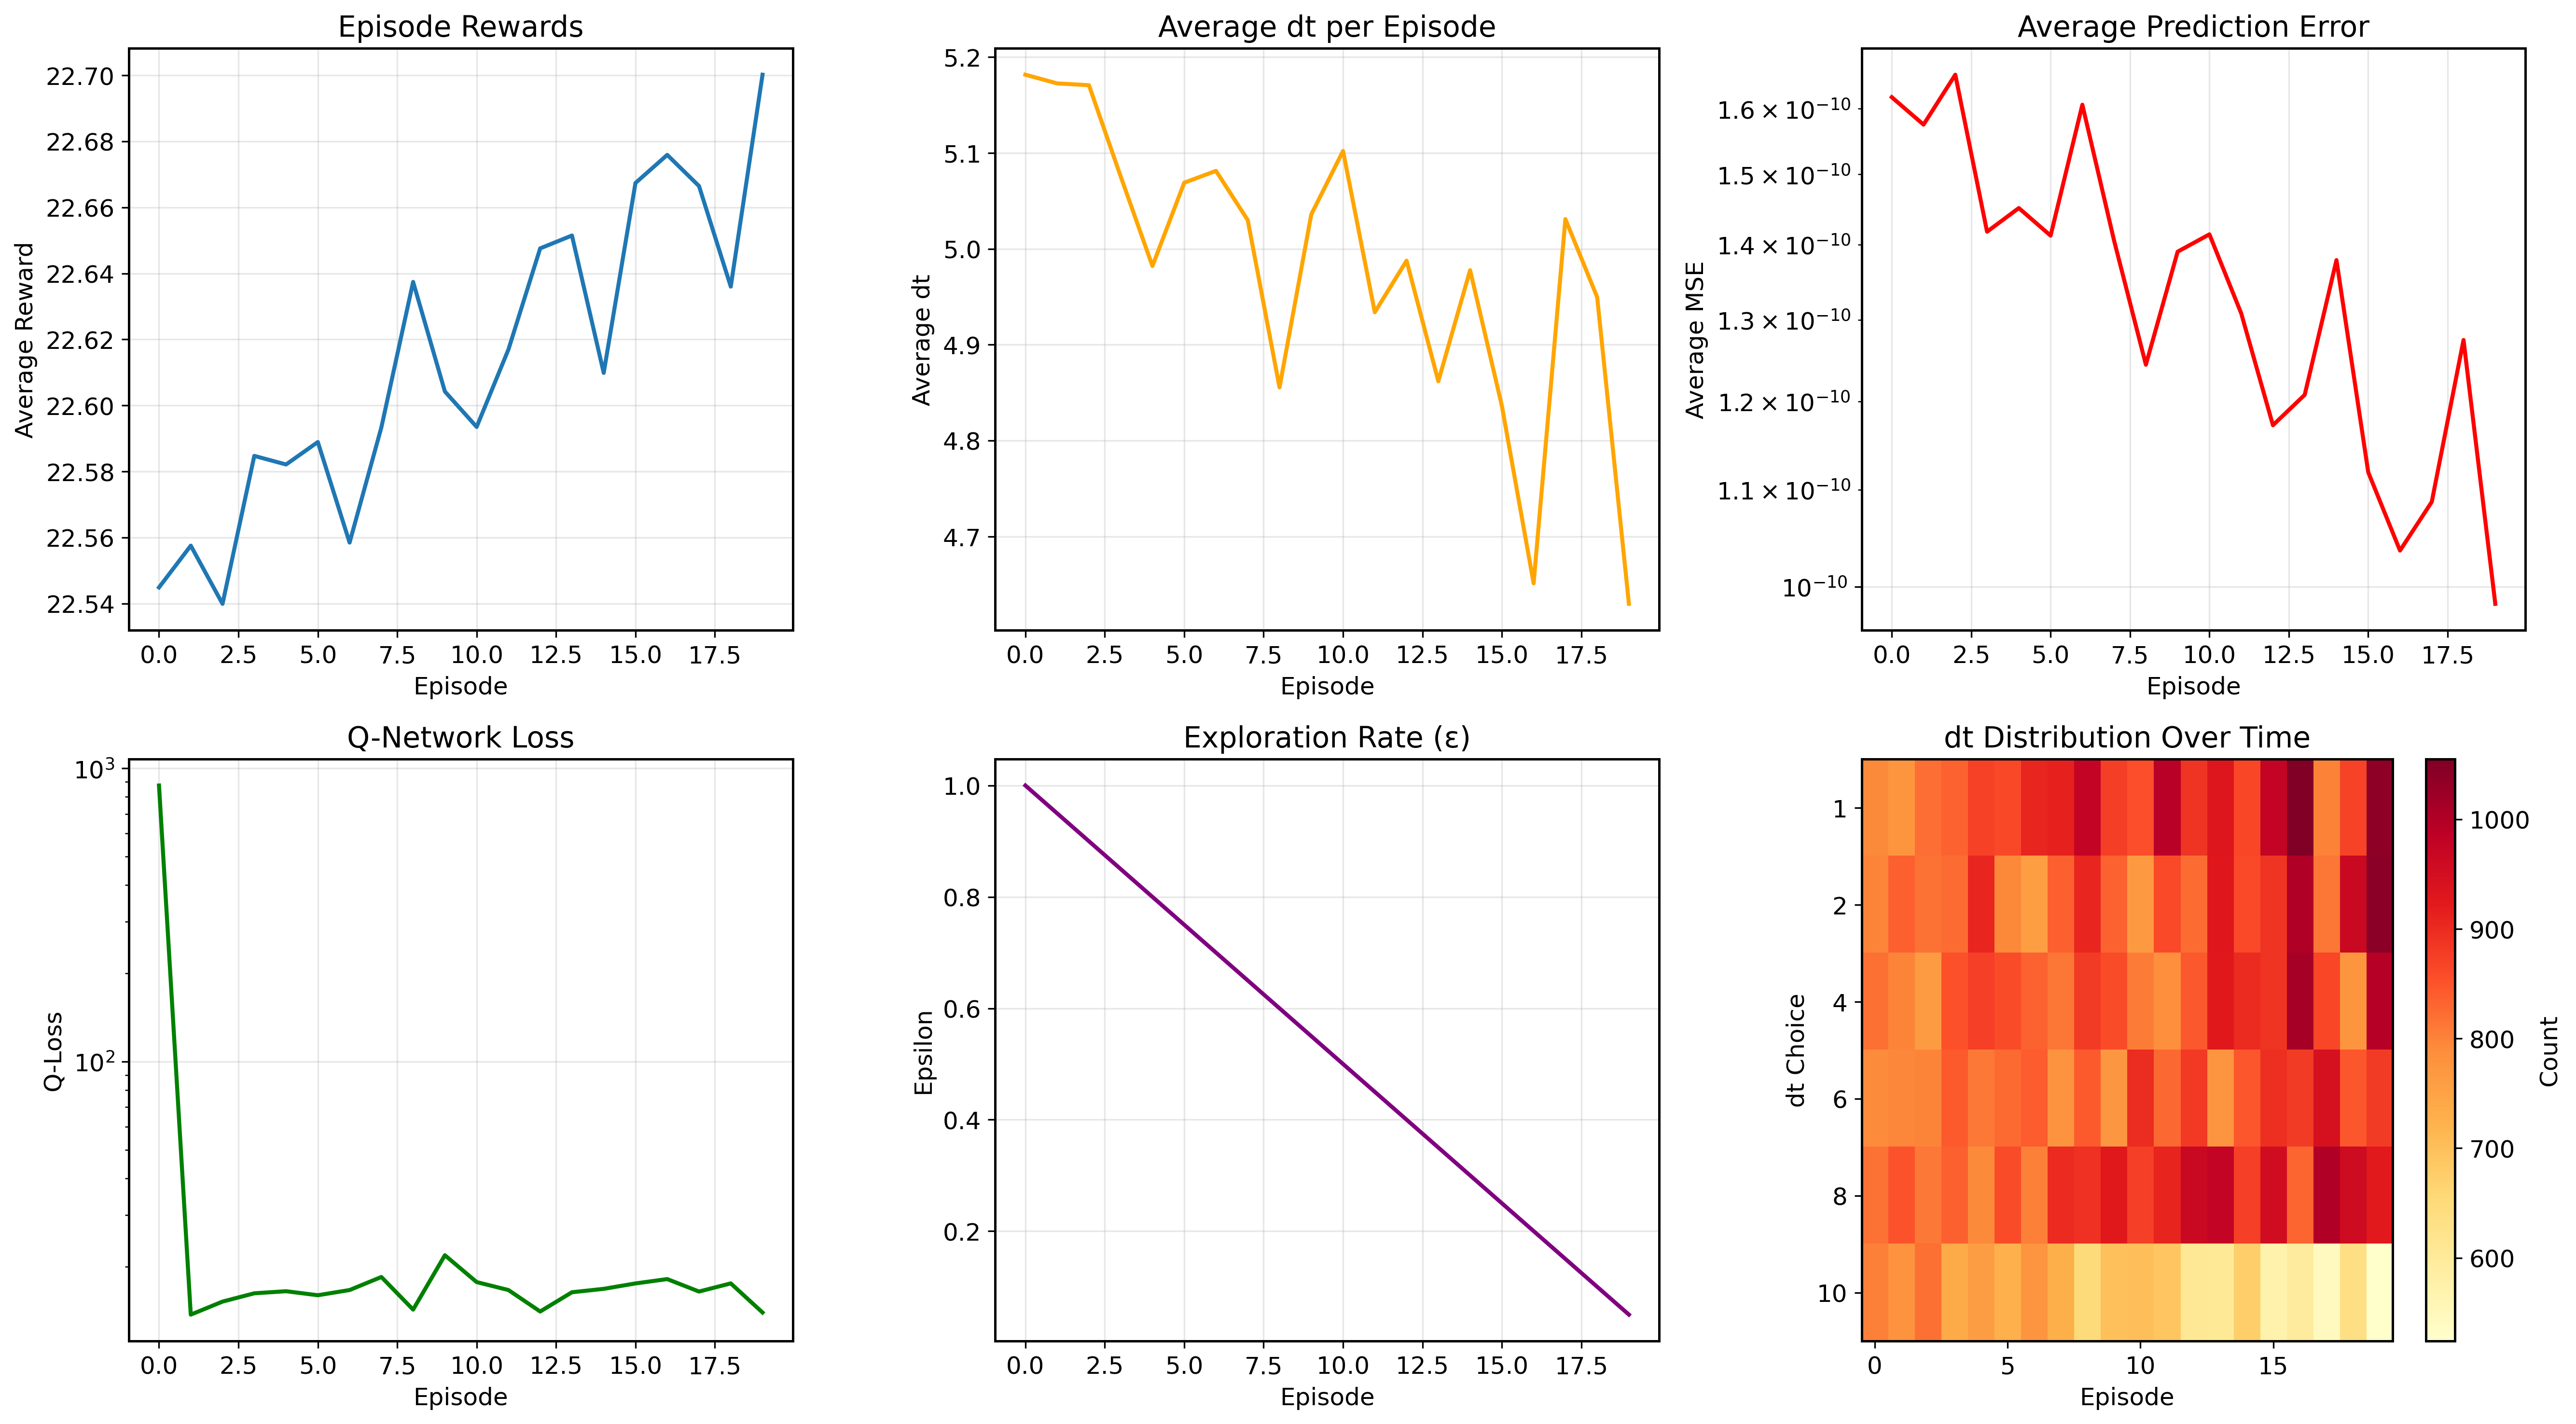

In [135]:
# ============================================================
# 7. Plot Training Results
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Episode Rewards
axes[0, 0].plot(episode_rewards, linewidth=2)
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("Average Reward")
axes[0, 0].set_title("Episode Rewards")
axes[0, 0].grid(True)

# 2. Average dt
axes[0, 1].plot(episode_avg_dt, linewidth=2, color='orange')
axes[0, 1].set_xlabel("Episode")
axes[0, 1].set_ylabel("Average dt")
axes[0, 1].set_title("Average dt per Episode")
axes[0, 1].grid(True)

# 3. Average Error
axes[0, 2].plot(episode_avg_error, linewidth=2, color='red')
axes[0, 2].set_xlabel("Episode")
axes[0, 2].set_ylabel("Average MSE")
axes[0, 2].set_title("Average Prediction Error")
axes[0, 2].set_yscale('log')
axes[0, 2].grid(True)

# 4. Q-Loss
axes[1, 0].plot(episode_q_loss, linewidth=2, color='green')
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylabel("Q-Loss")
axes[1, 0].set_title("Q-Network Loss")
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True)

# 5. Epsilon decay
axes[1, 1].plot(epsilon_history, linewidth=2, color='purple')
axes[1, 1].set_xlabel("Episode")
axes[1, 1].set_ylabel("Epsilon")
axes[1, 1].set_title("Exploration Rate (ε)")
axes[1, 1].grid(True)

# 6. dt Distribution over time (heatmap)
dt_choices = q_network.dt_choices
dt_matrix = np.zeros((len(episode_dt_distribution), len(dt_choices)))
for i, dist in enumerate(episode_dt_distribution):
    for j, dt in enumerate(dt_choices):
        dt_matrix[i, j] = dist.get(dt, 0)

im = axes[1, 2].imshow(dt_matrix.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
axes[1, 2].set_xlabel("Episode")
axes[1, 2].set_ylabel("dt Choice")
axes[1, 2].set_title("dt Distribution Over Time")
axes[1, 2].set_yticks(range(len(dt_choices)))
axes[1, 2].set_yticklabels(dt_choices)
plt.colorbar(im, ax=axes[1, 2], label='Count')

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 8. Test Learned Policy
# ============================================================
# NOTE: During training, avg dt reflects exploration (epsilon-greedy).
# During testing, you can set epsilon > 0 to see if the agent would explore different actions.
# This helps understand if the agent is truly confident or just converged to one action.

print("Testing learned Q-network on test data...")
print("="*60)

# Test with configurable epsilon
# epsilon = 0.0: pure exploitation (see what the learned policy does)
# epsilon > 0: some exploration (see if agent would try other actions)
test_epsilon =0.3  # Try 0.0 for pure exploitation, or 0.1-0.2 to see exploration
print(f"Test epsilon: {test_epsilon} ({'exploration' if test_epsilon > 0 else 'pure exploitation'})")
print()

t = 0
u_current = u_test_true[t].to(device)

test_dt_choices = []
test_errors = []
test_rewards = []
test_q_values_list = []  # Track Q-values to diagnose

while t < len(u_test_true) - max_dt:
    # Get state
    state = extract_state(u_current).unsqueeze(0).to(device)
    
    # Epsilon-greedy action selection (same as training)
    if random.random() < test_epsilon:
        # Explore: random action
        action_idx = random.randint(0, q_network.n_actions - 1)
    else:
        # Exploit: choose action with highest Q-value
        with torch.no_grad():
            q_values = q_network(state)
            action_idx = q_values.argmax().item()
    
    # Store Q-values for first few steps and periodically
    if len(test_dt_choices) < 5 or len(test_dt_choices) % 1000 == 0:
        with torch.no_grad():
            q_values = q_network(state)
            test_q_values_list.append(q_values.cpu().numpy()[0])
    
    dt_mult = q_network.dt_choices[action_idx]
    
    if t + dt_mult >= len(u_test_true):
        break
    
    test_dt_choices.append(dt_mult)
    
    # Predict next state
    u_pred = stepper_vectorized(u_current, dt_mult)
    u_next = u_test_true[t + dt_mult].to(device)
    
    # Compute error and reward (same structure as training)
    error = torch.mean((u_pred - u_next) ** 2).item()
    accuracy_reward = -np.log(error + 1e-10)
    
    # Compute gradient magnitude for adaptive reward (same as training)
    u_t = u_current.to(device) if isinstance(u_current, torch.Tensor) else u_current.to(device)
    u_left = torch.roll(u_t, +1, dims=-1)
    u_right = torch.roll(u_t, -1, dims=-1)
    gradient_mag = torch.mean(torch.abs(u_right - u_left)).item()
    gradient_norm = min(gradient_mag * 100, 1.0)  # Scale gradient to roughly [0,1]
    
    # Use same reward structure as training
    speed_reward = speed_bonus * dt_mult  # Direct reward proportional to dt_mult
    gradient_penalty = gradient_penalty_coeff * dt_mult * gradient_norm
    max_dt_penalty_val = max_dt_penalty if dt_mult == max_dt else 0.0
    reward = accuracy_reward + speed_reward - gradient_penalty - max_dt_penalty_val
    
    test_errors.append(error)
    test_rewards.append(reward)
    
    u_current = u_next
    t += dt_mult

# Print statistics
print(f"Test steps: {len(test_dt_choices)}")
print(f"Average dt: {np.mean(test_dt_choices):.2f}")
print(f"Average error: {np.mean(test_errors):.2e}")
print(f"Average reward: {np.mean(test_rewards):.2f}")
print(f"\ndt distribution (epsilon={test_epsilon}):")
dt_counts = {dt: test_dt_choices.count(dt) for dt in q_network.dt_choices}
for dt in q_network.dt_choices:
    count = dt_counts.get(dt, 0)
    percentage = 100 * count / len(test_dt_choices) if len(test_dt_choices) > 0 else 0
    print(f"  dt={dt:2d}: {count:4d} ({percentage:5.1f}%)")

# Compare with expected random distribution if exploring
if test_epsilon > 0:
    expected_random_pct = 100.0 / len(q_network.dt_choices)
    print(f"\nExpected random distribution: {expected_random_pct:.1f}% per action")
    print("If distribution is close to random, the agent hasn't learned strong preferences.")
    print("If one action dominates, the agent has learned a clear preference.")

# Diagnose Q-value distribution
if len(test_q_values_list) > 0:
    print(f"\nQ-Value Analysis (sampled from {len(test_q_values_list)} states):")
    avg_q_values = np.mean(test_q_values_list, axis=0)
    std_q_values = np.std(test_q_values_list, axis=0)
    print("Average Q-values per action:")
    for i, dt in enumerate(q_network.dt_choices):
        print(f"  dt={dt:2d}: Q = {avg_q_values[i]:7.2f} ± {std_q_values[i]:.2f}")
    
    # Check if Q-values are too similar (indicating poor learning)
    q_range = np.max(avg_q_values) - np.min(avg_q_values)
    if q_range < 1.0:
        print(f"\n⚠ Warning: Q-values are very similar (range = {q_range:.2f})")
        print("  This suggests the network hasn't learned to distinguish between actions.")
        print("  Possible causes:")
        print("    - Reward structure makes all actions equally good")
        print("    - Need more training episodes")
        print("    - Need better state representation")
    else:
        max_q_idx = np.argmax(avg_q_values)
        print(f"\n✓ Q-values show clear preference: dt={q_network.dt_choices[max_q_idx]} "
              f"(Q = {avg_q_values[max_q_idx]:.2f})")
        print(f"  This explains why the agent always chooses dt={q_network.dt_choices[max_q_idx]}")

print("="*60)


Testing learned Q-network on test data...
Test epsilon: 0.3 (exploration)

Test steps: 8434
Average dt: 2.96
Average error: 7.93e-12
Average reward: 23.59

dt distribution (epsilon=0.3):
  dt= 1:  396 (  4.7%)
  dt= 2: 6333 ( 75.1%)
  dt= 4:  429 (  5.1%)
  dt= 6:  419 (  5.0%)
  dt= 8:  435 (  5.2%)
  dt=10:  422 (  5.0%)

Expected random distribution: 16.7% per action
If distribution is close to random, the agent hasn't learned strong preferences.
If one action dominates, the agent has learned a clear preference.

Q-Value Analysis (sampled from 13 states):
Average Q-values per action:
  dt= 1: Q = 2499.41 ± 0.04
  dt= 2: Q = 2500.84 ± 0.04
  dt= 4: Q = 2494.57 ± 0.04
  dt= 6: Q = 2494.54 ± 0.04
  dt= 8: Q = 2497.55 ± 0.04
  dt=10: Q = 2496.96 ± 0.04

✓ Q-values show clear preference: dt=2 (Q = 2500.84)
  This explains why the agent always chooses dt=2


Collected 5000 steps for analysis



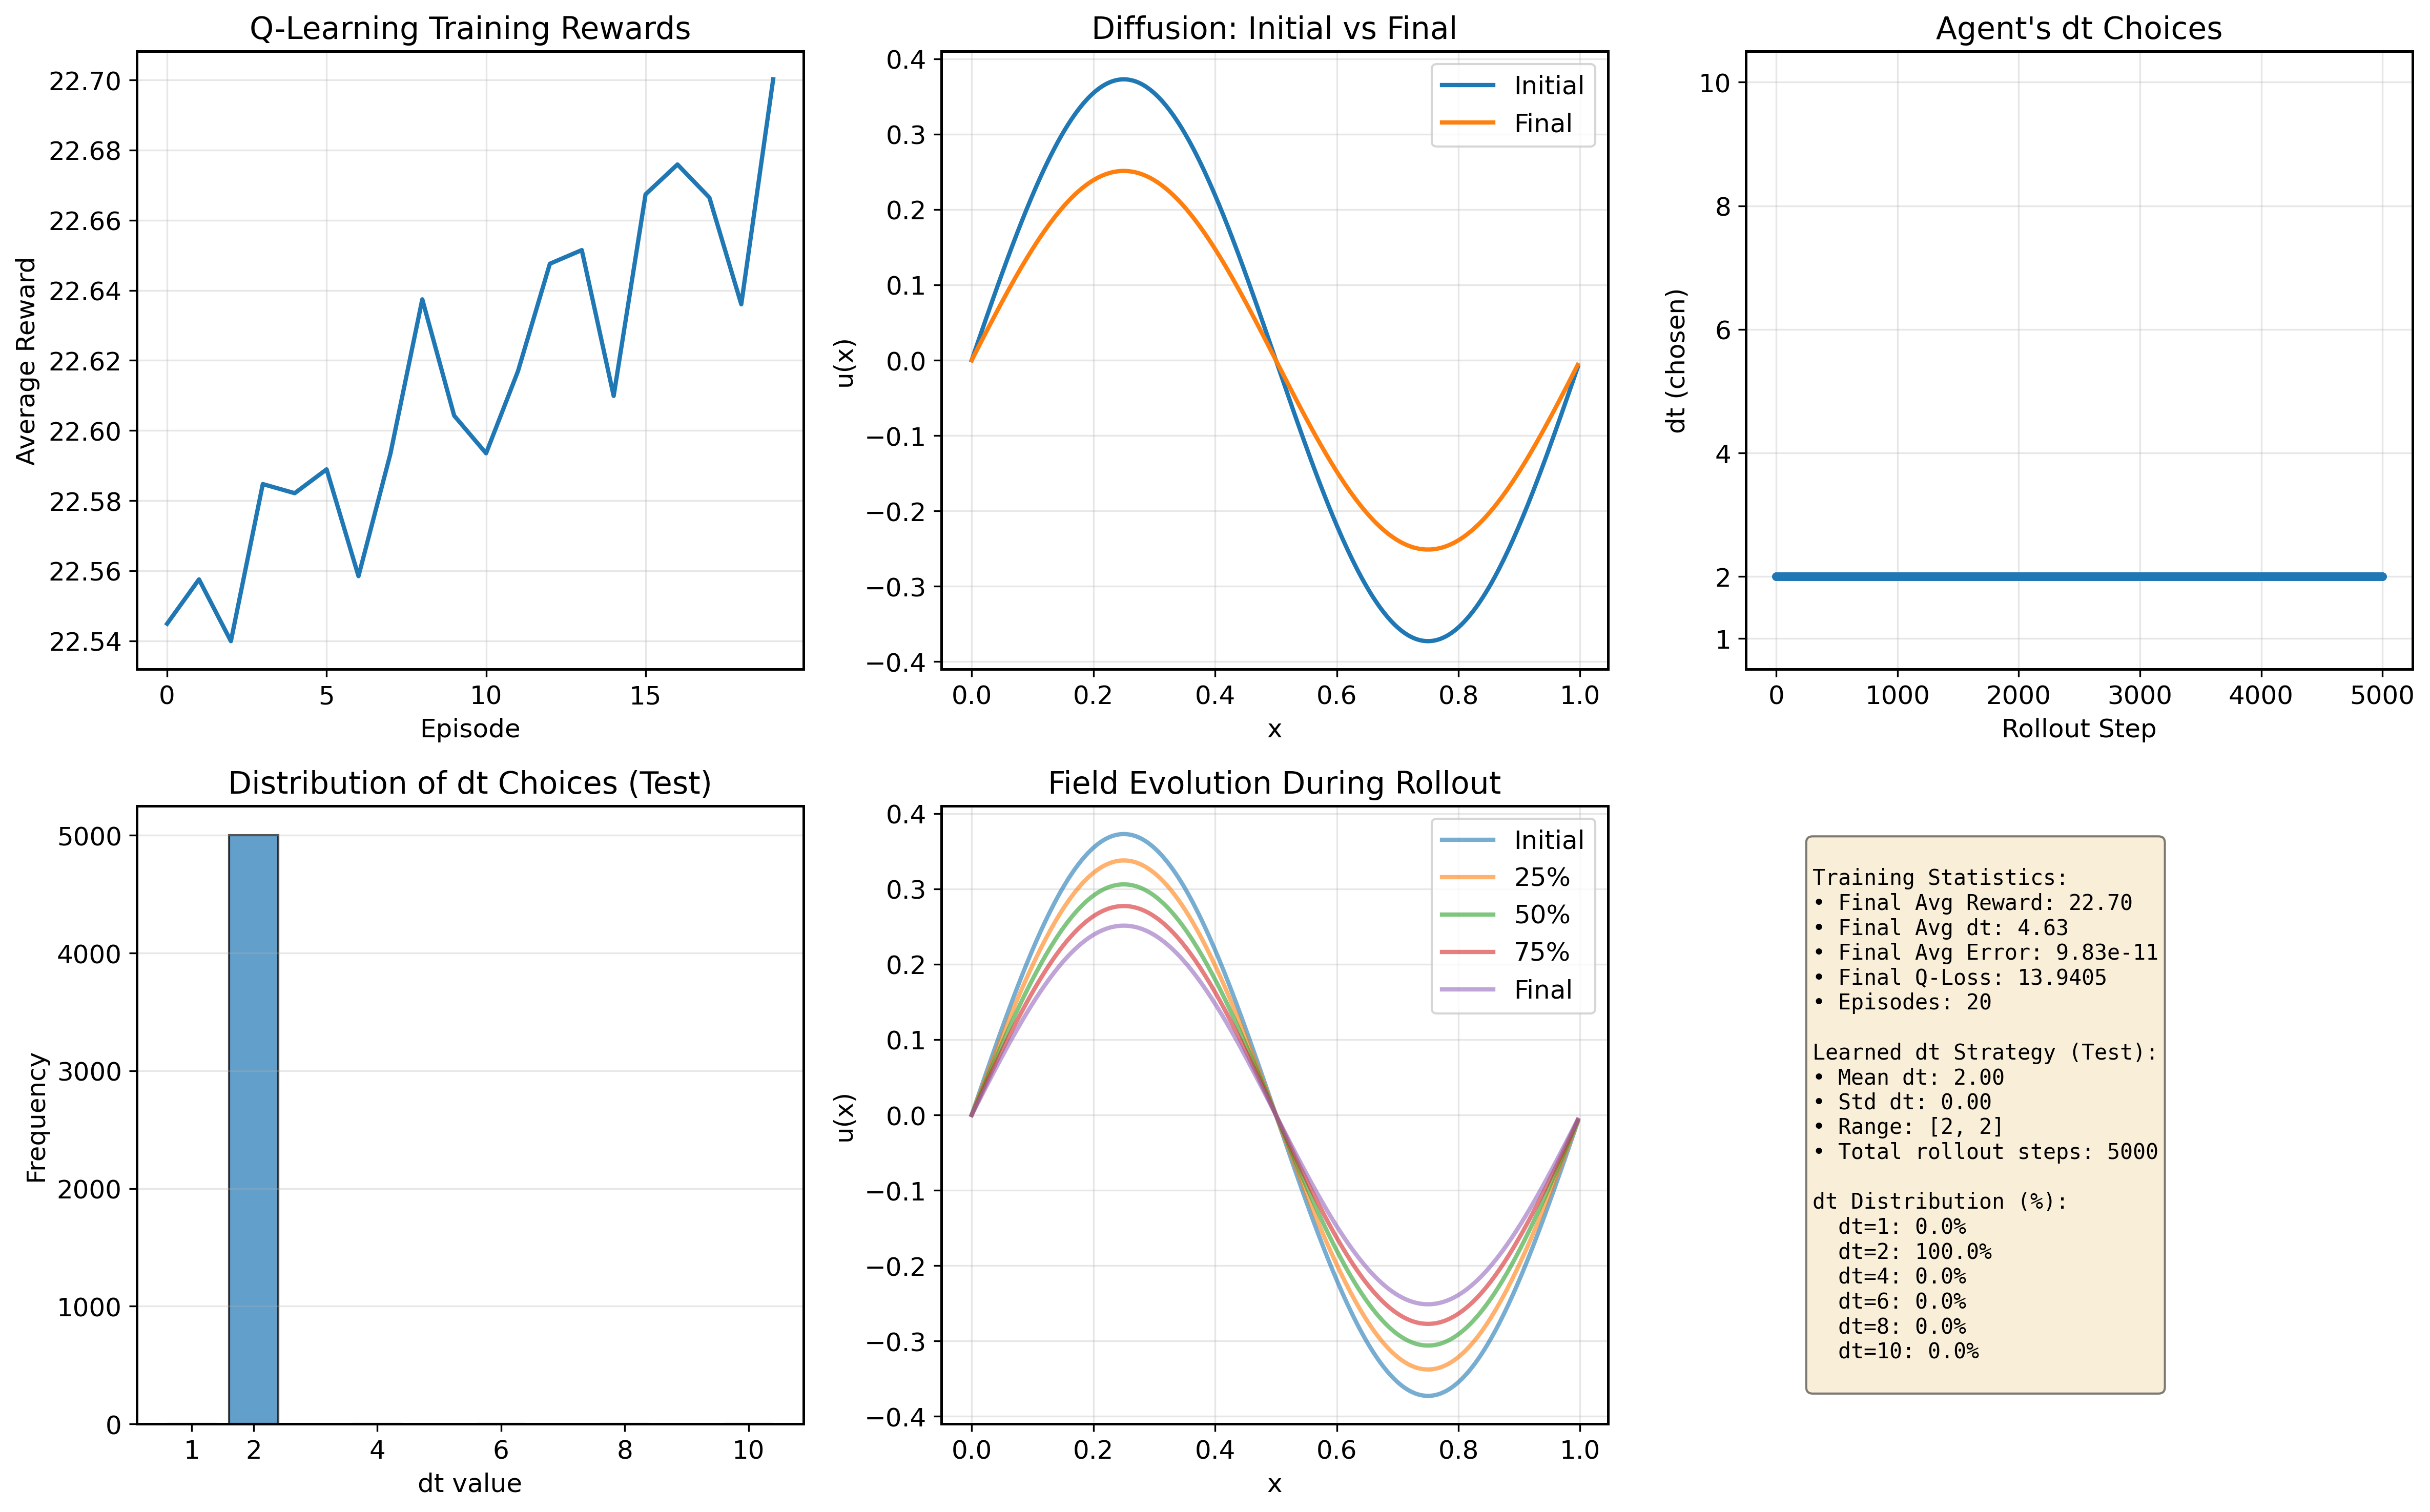

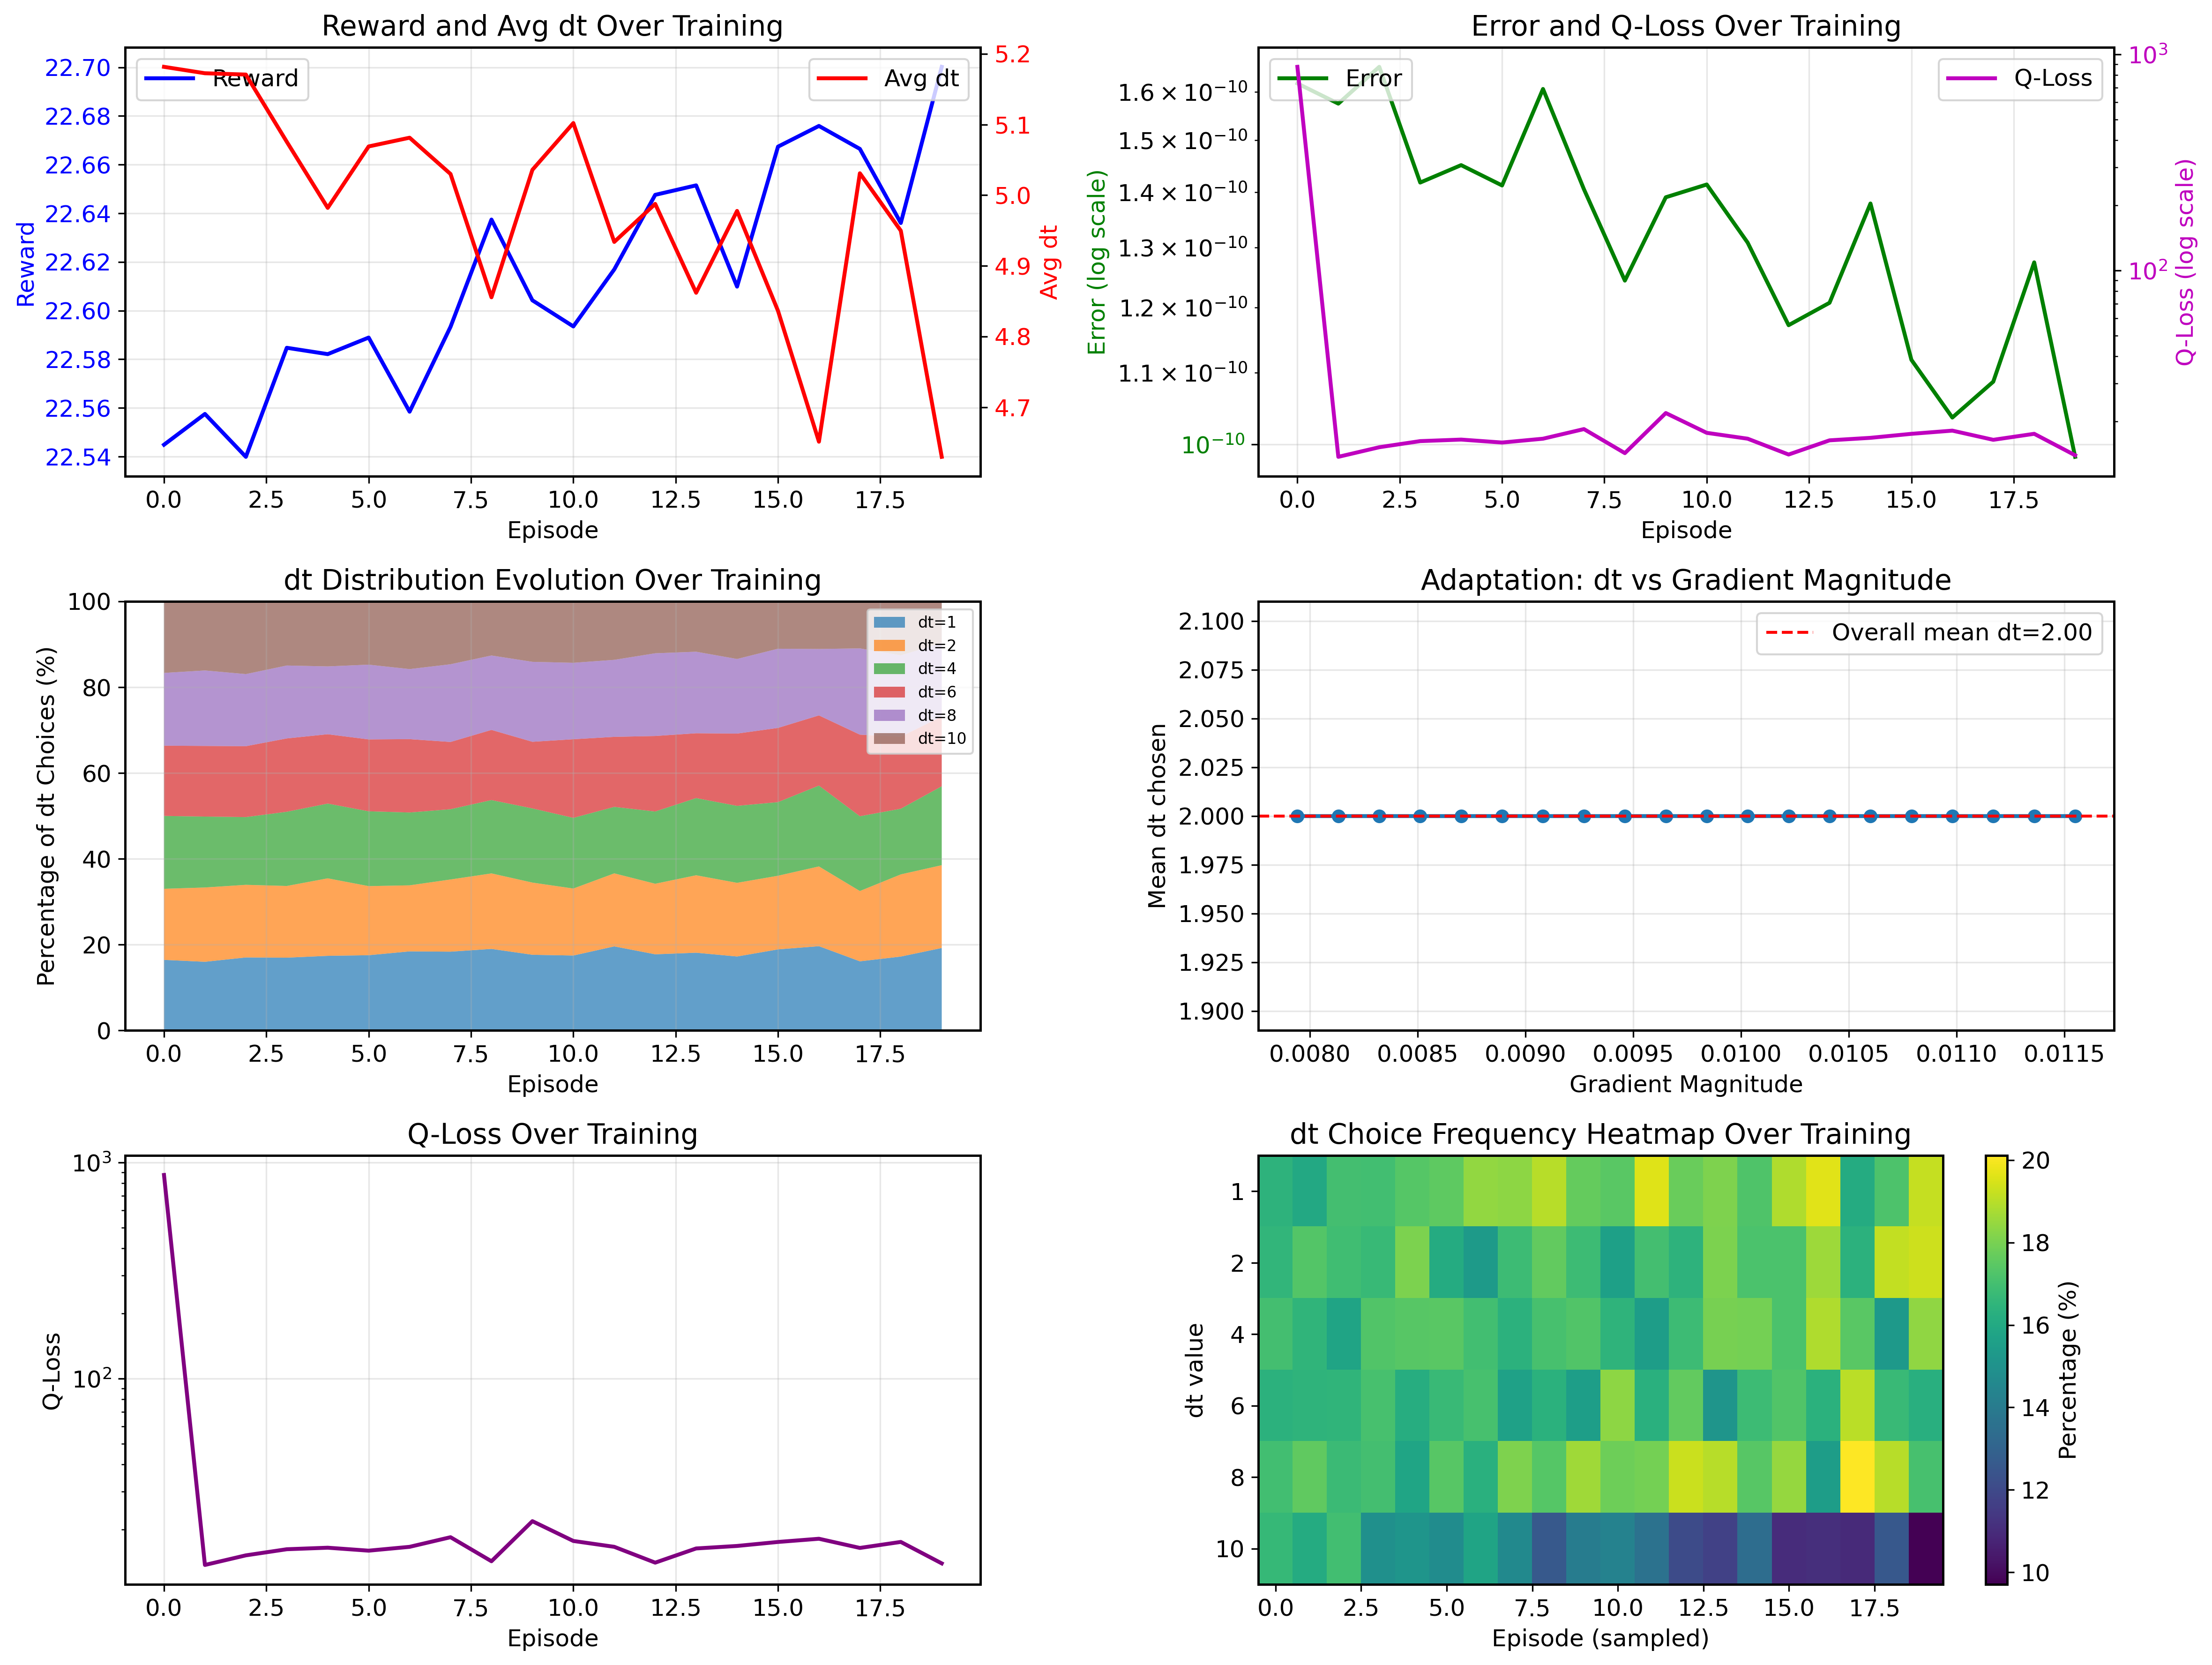

ANALYSIS SUMMARY
Q-Value Range: 2494.50 to 2500.86
Q-Value Spread (std): 2.32

Action with highest Q-value per step:
  dt= 1:    0 steps (  0.0%)
  dt= 2: 5000 steps (100.0%)
  dt= 4:    0 steps (  0.0%)
  dt= 6:    0 steps (  0.0%)
  dt= 8:    0 steps (  0.0%)
  dt=10:    0 steps (  0.0%)

ADAPTATION ANALYSIS
Low gradient regions (grad < 0.009560):
  Mean dt: 2.00, Std: 0.00
  Count: 2500

High gradient regions (grad >= 0.009560):
  Mean dt: 2.00, Std: 0.00
  Count: 2500

⚠ WARNING: Agent uses smaller dt (2.00) in low-gradient regions
            and larger dt (2.00) in high-gradient regions.
            This is opposite of expected behavior.


In [ ]:
# ============================================================
# 10. Comprehensive Analysis Plots (Similar to 4. second RL Stage)
# ============================================================

# Re-run test to collect detailed data for analysis
print("Collecting data for comprehensive analysis...")
test_epsilon_analysis = 0.5 # Pure exploitation for analysis
t = 0
u_current = u_test_true[t].to(device)

analysis_dt_choices = []
analysis_errors = []
analysis_rewards = []
analysis_q_values_all = []
analysis_states = []
analysis_gradients = []  # Track gradients

while t < len(u_test_true) - max_dt and len(analysis_dt_choices) < 5000:  # More steps for better analysis
    state = extract_state(u_current).unsqueeze(0).to(device)
    
    # Compute gradient for analysis
    u_t = u_current.to(device) if isinstance(u_current, torch.Tensor) else torch.tensor(u_current, device=device)
    u_left = torch.roll(u_t, +1, dims=-1)
    u_right = torch.roll(u_t, -1, dims=-1)
    gradient_mag = torch.mean(torch.abs(u_right - u_left)).item()
    
    with torch.no_grad():
        q_values = q_network(state)
        action_idx = q_values.argmax().item()
    
    dt_mult = q_network.dt_choices[action_idx]
    
    if t + dt_mult >= len(u_test_true):
        break
    
    # Predict and compute metrics (same reward structure as training)
    u_pred = stepper_vectorized(u_current, dt_mult)
    u_next = u_test_true[t + dt_mult].to(device)
    error = torch.mean((u_pred - u_next) ** 2).item()
    accuracy_reward = -np.log(error + 1e-10)
    
    # Compute gradient norm for adaptive reward
    gradient_norm = min(gradient_mag * 100, 1.0)  # Scale gradient to roughly [0,1]
    
    # Use same reward structure as training
    speed_reward = speed_bonus * dt_mult  # Direct reward proportional to dt_mult
    gradient_penalty = gradient_penalty_coeff * dt_mult * gradient_norm
    max_dt_penalty_val = max_dt_penalty if dt_mult == max_dt else 0.0
    reward = accuracy_reward + speed_reward - gradient_penalty - max_dt_penalty_val
    
    analysis_dt_choices.append(dt_mult)
    analysis_errors.append(error)
    analysis_rewards.append(reward)
    analysis_q_values_all.append(q_values.cpu().numpy()[0])
    analysis_states.append(u_current.cpu().numpy() if isinstance(u_current, np.ndarray) else u_current.cpu().numpy())
    analysis_gradients.append(gradient_mag)
    
    u_current = u_next
    t += dt_mult

print(f"Collected {len(analysis_dt_choices)} steps for analysis\n")

# Generate spatial coordinate array if not available
if 'x' not in globals() or len(x) != Nx:
    x = np.linspace(0, 1, Nx, endpoint=False)

# Get initial and final states from test data for comparison
if len(analysis_states) > 0:
    initial_state = analysis_states[0]
    final_state = analysis_states[-1]
else:
    # Fallback: use test data
    initial_state = u_test_true[0].cpu().numpy()
    final_state = u_test_true[-1].cpu().numpy()

# ============================================================
# Main Results Plot (2x3 grid, similar to second RL Stage)
# ============================================================
fig = plt.figure(figsize=(16, 10))

# 1. Training Rewards
ax1 = plt.subplot(2, 3, 1)
ax1.plot(episode_rewards, linewidth=2)
ax1.set_xlabel("Episode")
ax1.set_ylabel("Average Reward")
ax1.set_title("Q-Learning Training Rewards")
ax1.grid(True)

# 2. Diffusion Evolution
ax2 = plt.subplot(2, 3, 2)
ax2.plot(x, initial_state, label="Initial", linewidth=2)
ax2.plot(x, final_state, label="Final", linewidth=2)
ax2.set_xlabel("x")
ax2.set_ylabel("u(x)")
ax2.set_title("Diffusion: Initial vs Final")
ax2.legend()
ax2.grid(True)

# 3. dt Choices Over Time
ax3 = plt.subplot(2, 3, 3)
ax3.plot(analysis_dt_choices, marker='o', markersize=3, linewidth=1)
ax3.set_xlabel("Rollout Step")
ax3.set_ylabel("dt (chosen)")
ax3.set_title("Agent's dt Choices")
ax3.set_ylim([0.5, 10.5])
ax3.set_yticks(q_network.dt_choices)
ax3.grid(True)

# 4. dt Histogram
ax4 = plt.subplot(2, 3, 4)
dt_counts = {dt: analysis_dt_choices.count(dt) for dt in q_network.dt_choices}
ax4.bar(dt_counts.keys(), dt_counts.values(), edgecolor='black', alpha=0.7)
ax4.set_xlabel("dt value")
ax4.set_ylabel("Frequency")
ax4.set_title("Distribution of dt Choices (Test)")
ax4.set_xticks(q_network.dt_choices)
ax4.grid(True, alpha=0.3, axis='y')

# 5. Field Evolution at Key Times
ax5 = plt.subplot(2, 3, 5)
sample_indices = [0, len(analysis_states)//4, len(analysis_states)//2, 
                  3*len(analysis_states)//4, len(analysis_states)-1]
labels = ["Initial", "25%", "50%", "75%", "Final"]
for i, idx in enumerate(sample_indices):
    if idx < len(analysis_states):
        field_val = analysis_states[idx]
        ax5.plot(x, field_val, alpha=0.6, label=labels[i], linewidth=2)
ax5.set_xlabel("x")
ax5.set_ylabel("u(x)")
ax5.set_title("Field Evolution During Rollout")
ax5.legend()
ax5.grid(True)

# 6. Statistics Summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
dt_dist_pct = {dt: 100*analysis_dt_choices.count(dt)/len(analysis_dt_choices) 
               for dt in q_network.dt_choices}

stats_text = f"""
Training Statistics:
• Final Avg Reward: {episode_rewards[-1]:.2f}
• Final Avg dt: {episode_avg_dt[-1]:.2f}
• Final Avg Error: {episode_avg_error[-1]:.2e}
• Final Q-Loss: {episode_q_loss[-1]:.4f}
• Episodes: {n_episodes}

Learned dt Strategy (Test):
• Mean dt: {np.mean(analysis_dt_choices):.2f}
• Std dt: {np.std(analysis_dt_choices):.2f}
• Range: [{np.min(analysis_dt_choices)}, {np.max(analysis_dt_choices)}]
• Total rollout steps: {len(analysis_dt_choices)}

dt Distribution (%):
{chr(10).join([f'  dt={dt}: {dt_dist_pct[dt]:.1f}%' for dt in q_network.dt_choices])}
"""
ax6.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# ============================================================
# Diagnostic Plots (3x2 grid, similar to second RL Stage)
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# 1. Reward and Avg dt Over Training
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
ax1.plot(episode_rewards, 'b-', label='Reward', linewidth=2)
ax1_twin.plot(episode_avg_dt, 'r-', label='Avg dt', linewidth=2)
ax1.set_xlabel("Episode")
ax1.set_ylabel("Reward", color='b')
ax1_twin.set_ylabel("Avg dt", color='r')
ax1.set_title("Reward and Avg dt Over Training")
ax1.tick_params(axis='y', labelcolor='b')
ax1_twin.tick_params(axis='y', labelcolor='r')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# 2. Error and Q-Loss Over Training
ax2 = axes[0, 1]
ax2_twin = ax2.twinx()
ax2.semilogy(episode_avg_error, 'g-', label='Error', linewidth=2)
ax2_twin.semilogy(episode_q_loss, 'm-', label='Q-Loss', linewidth=2)
ax2.set_xlabel("Episode")
ax2.set_ylabel("Error (log scale)", color='g')
ax2_twin.set_ylabel("Q-Loss (log scale)", color='m')
ax2.set_title("Error and Q-Loss Over Training")
ax2.tick_params(axis='y', labelcolor='g')
ax2_twin.tick_params(axis='y', labelcolor='m')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

# 3. dt Distribution Evolution (stacked area)
ax3 = axes[1, 0]
if len(episode_dt_distribution) > 0:
    dt_dist_matrix = np.zeros((len(episode_dt_distribution), len(q_network.dt_choices)))
    for i, dist in enumerate(episode_dt_distribution):
        for j, dt in enumerate(q_network.dt_choices):
            dt_dist_matrix[i, j] = dist.get(dt, 0)
    
    # Normalize to percentages
    dt_dist_pct = dt_dist_matrix / (dt_dist_matrix.sum(axis=1, keepdims=True) + 1e-8) * 100
    
    ax3.stackplot(range(len(episode_dt_distribution)), 
                  *[dt_dist_pct[:, i] for i in range(len(q_network.dt_choices))],
                  labels=[f'dt={dt}' for dt in q_network.dt_choices],
                  alpha=0.7)
    ax3.set_xlabel("Episode")
    ax3.set_ylabel("Percentage of dt Choices (%)")
    ax3.set_title("dt Distribution Evolution Over Training")
    ax3.legend(loc='upper right', fontsize=8)
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim([0, 100])
else:
    ax3.text(0.5, 0.5, 'No data available', ha='center', va='center', 
             transform=ax3.transAxes, fontsize=12)
    ax3.set_title("dt Distribution Evolution Over Training")
    ax3.axis('off')

# 4. dt vs Gradient (adaptation analysis)
ax4 = axes[1, 1]
if len(analysis_gradients) > 0 and len(analysis_dt_choices) > 0:
    # Create bins for gradient
    n_bins = 20
    grad_bins = np.linspace(min(analysis_gradients), max(analysis_gradients), n_bins+1)
    bin_centers = (grad_bins[:-1] + grad_bins[1:]) / 2
    
    # Compute mean dt for each bin
    mean_dt_per_bin = []
    for i in range(n_bins):
        mask = (np.array(analysis_gradients) >= grad_bins[i]) & (np.array(analysis_gradients) < grad_bins[i+1])
        if mask.sum() > 0:
            mean_dt_per_bin.append(np.mean([analysis_dt_choices[j] for j in range(len(analysis_dt_choices)) if mask[j]]))
        else:
            mean_dt_per_bin.append(np.nan)
    
    ax4.plot(bin_centers, mean_dt_per_bin, 'o-', linewidth=2, markersize=6)
    ax4.set_xlabel("Gradient Magnitude")
    ax4.set_ylabel("Mean dt chosen")
    ax4.set_title("Adaptation: dt vs Gradient Magnitude")
    ax4.grid(True, alpha=0.3)
    ax4.axhline(y=np.mean(analysis_dt_choices), color='r', linestyle='--', 
                label=f'Overall mean dt={np.mean(analysis_dt_choices):.2f}')
    ax4.legend()
else:
    ax4.text(0.5, 0.5, 'No gradient data available', ha='center', va='center', 
             transform=ax4.transAxes, fontsize=12)
    ax4.set_title("Adaptation: dt vs Gradient Magnitude")
    ax4.axis('off')

# 5. Q-Loss Over Training
ax5 = axes[2, 0]
ax5.plot(episode_q_loss, 'purple', linewidth=2)
ax5.set_xlabel("Episode")
ax5.set_ylabel("Q-Loss")
ax5.set_title("Q-Loss Over Training")
ax5.grid(True, alpha=0.3)
ax5.set_yscale('log')

# 6. dt Choice Frequency Heatmap (over episodes)
ax6 = axes[2, 1]
if len(episode_dt_distribution) > 0:
    # Sample episodes
    sample_episodes = list(range(0, len(episode_dt_distribution), max(1, len(episode_dt_distribution)//20)))
    if len(sample_episodes) > 0:
        heatmap_data = np.zeros((len(sample_episodes), len(q_network.dt_choices)))
        for i, ep_idx in enumerate(sample_episodes):
            dist = episode_dt_distribution[ep_idx]
            total = sum(dist.values())
            for j, dt in enumerate(q_network.dt_choices):
                heatmap_data[i, j] = dist.get(dt, 0) / (total + 1e-8) * 100
        
        im = ax6.imshow(heatmap_data.T, aspect='auto', cmap='viridis', interpolation='nearest')
        ax6.set_xlabel("Episode (sampled)")
        ax6.set_ylabel("dt value")
        ax6.set_yticks(range(len(q_network.dt_choices)))
        ax6.set_yticklabels(q_network.dt_choices)
        ax6.set_title("dt Choice Frequency Heatmap Over Training")
        plt.colorbar(im, ax=ax6, label="Percentage (%)")
    else:
        ax6.text(0.5, 0.5, 'Not enough data', ha='center', va='center', 
                 transform=ax6.transAxes, fontsize=12)
        ax6.axis('off')
else:
    ax6.text(0.5, 0.5, 'No data available', ha='center', va='center', 
             transform=ax6.transAxes, fontsize=12)
    ax6.axis('off')

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*60)
print("ANALYSIS SUMMARY")
print("="*60)
print(f"Q-Value Range: {np.min(analysis_q_values_all):.2f} to {np.max(analysis_q_values_all):.2f}")
print(f"Q-Value Spread (std): {np.std(analysis_q_values_all):.2f}")
if len(analysis_q_values_all) > 0:
    q_array = np.array(analysis_q_values_all)
    max_action_per_step = np.argmax(q_array, axis=1)
    max_action_counts = {dt: np.sum(max_action_per_step == i) 
                        for i, dt in enumerate(q_network.dt_choices)}
    print(f"\nAction with highest Q-value per step:")
    for dt in q_network.dt_choices:
        idx = q_network.dt_choices.index(dt)
        count = max_action_counts.get(dt, 0)
        pct = 100 * count / len(max_action_per_step)
        print(f"  dt={dt:2d}: {count:4d} steps ({pct:5.1f}%)")

# Adaptation Analysis
print("\n" + "="*60)
print("ADAPTATION ANALYSIS")
print("="*60)
if len(analysis_gradients) > 0 and len(analysis_dt_choices) > 0:
    # Split into low and high gradient regions
    grad_median = np.median(analysis_gradients)
    low_grad_mask = np.array(analysis_gradients) < grad_median
    high_grad_mask = np.array(analysis_gradients) >= grad_median
    
    low_grad_dt = [analysis_dt_choices[i] for i in range(len(analysis_dt_choices)) if low_grad_mask[i]]
    high_grad_dt = [analysis_dt_choices[i] for i in range(len(analysis_dt_choices)) if high_grad_mask[i]]
    
    print(f"Low gradient regions (grad < {grad_median:.6f}):")
    print(f"  Mean dt: {np.mean(low_grad_dt):.2f}, Std: {np.std(low_grad_dt):.2f}")
    print(f"  Count: {len(low_grad_dt)}")
    
    print(f"\nHigh gradient regions (grad >= {grad_median:.6f}):")
    print(f"  Mean dt: {np.mean(high_grad_dt):.2f}, Std: {np.std(high_grad_dt):.2f}")
    print(f"  Count: {len(high_grad_dt)}")
    
    # Check if adaptive behavior is learned
    if np.mean(low_grad_dt) > np.mean(high_grad_dt):
        print(f"\n✓ GOOD: Agent uses larger dt ({np.mean(low_grad_dt):.2f}) in low-gradient regions")
        print(f"         and smaller dt ({np.mean(high_grad_dt):.2f}) in high-gradient regions.")
        print("         This is the expected adaptive behavior!")
    else:
        print(f"\n⚠ WARNING: Agent uses smaller dt ({np.mean(low_grad_dt):.2f}) in low-gradient regions")
        print(f"            and larger dt ({np.mean(high_grad_dt):.2f}) in high-gradient regions.")
        print("            This is opposite of expected behavior.")
    
    # Correlation analysis
    dt_grad_means = {}
    for dt in q_network.dt_choices:
        dt_mask = [d == dt for d in analysis_dt_choices]
        if any(dt_mask):
            dt_gradients = [g for g, m in zip(analysis_gradients, dt_mask) if m]
            dt_grad_means[dt] = np.mean(dt_gradients)
    
    if len(dt_grad_means) > 1:
        dt_vals = sorted(dt_grad_means.keys())
        grad_vals = [dt_grad_means[dt] for dt in dt_vals]
        correlation = np.corrcoef(dt_vals, grad_vals)[0, 1]
        print(f"\nCorrelation (dt vs gradient): {correlation:.3f}")
        if correlation < -0.3:
            print("  ✓ Strong negative correlation - adaptive behavior detected!")
        elif correlation > 0.3:
            print("  ⚠ Positive correlation - opposite of expected behavior.")
        else:
            print("  ⚠ Weak correlation - may need more training or reward tuning.")
else:
    print("No gradient data available for analysis.")

print("="*60)


EPSILON COMPARISON ANALYSIS

Key Insight: With epsilon=1, you get uniform distribution (random exploration).
With epsilon=0, you see what the agent actually learned (pure exploitation).
The Q-values show dt=6 is preferred, but the difference is small (~4.66 range).

Testing with epsilon = 0.0...
  Steps: 2000, Avg dt: 2.00, Avg reward: 23.00
Testing with epsilon = 0.1...
  Steps: 2000, Avg dt: 2.34, Avg reward: 22.98
Testing with epsilon = 0.5...
  Steps: 2000, Avg dt: 3.69, Avg reward: 22.95
Testing with epsilon = 1.0...
  Steps: 2000, Avg dt: 5.25, Avg reward: 23.08



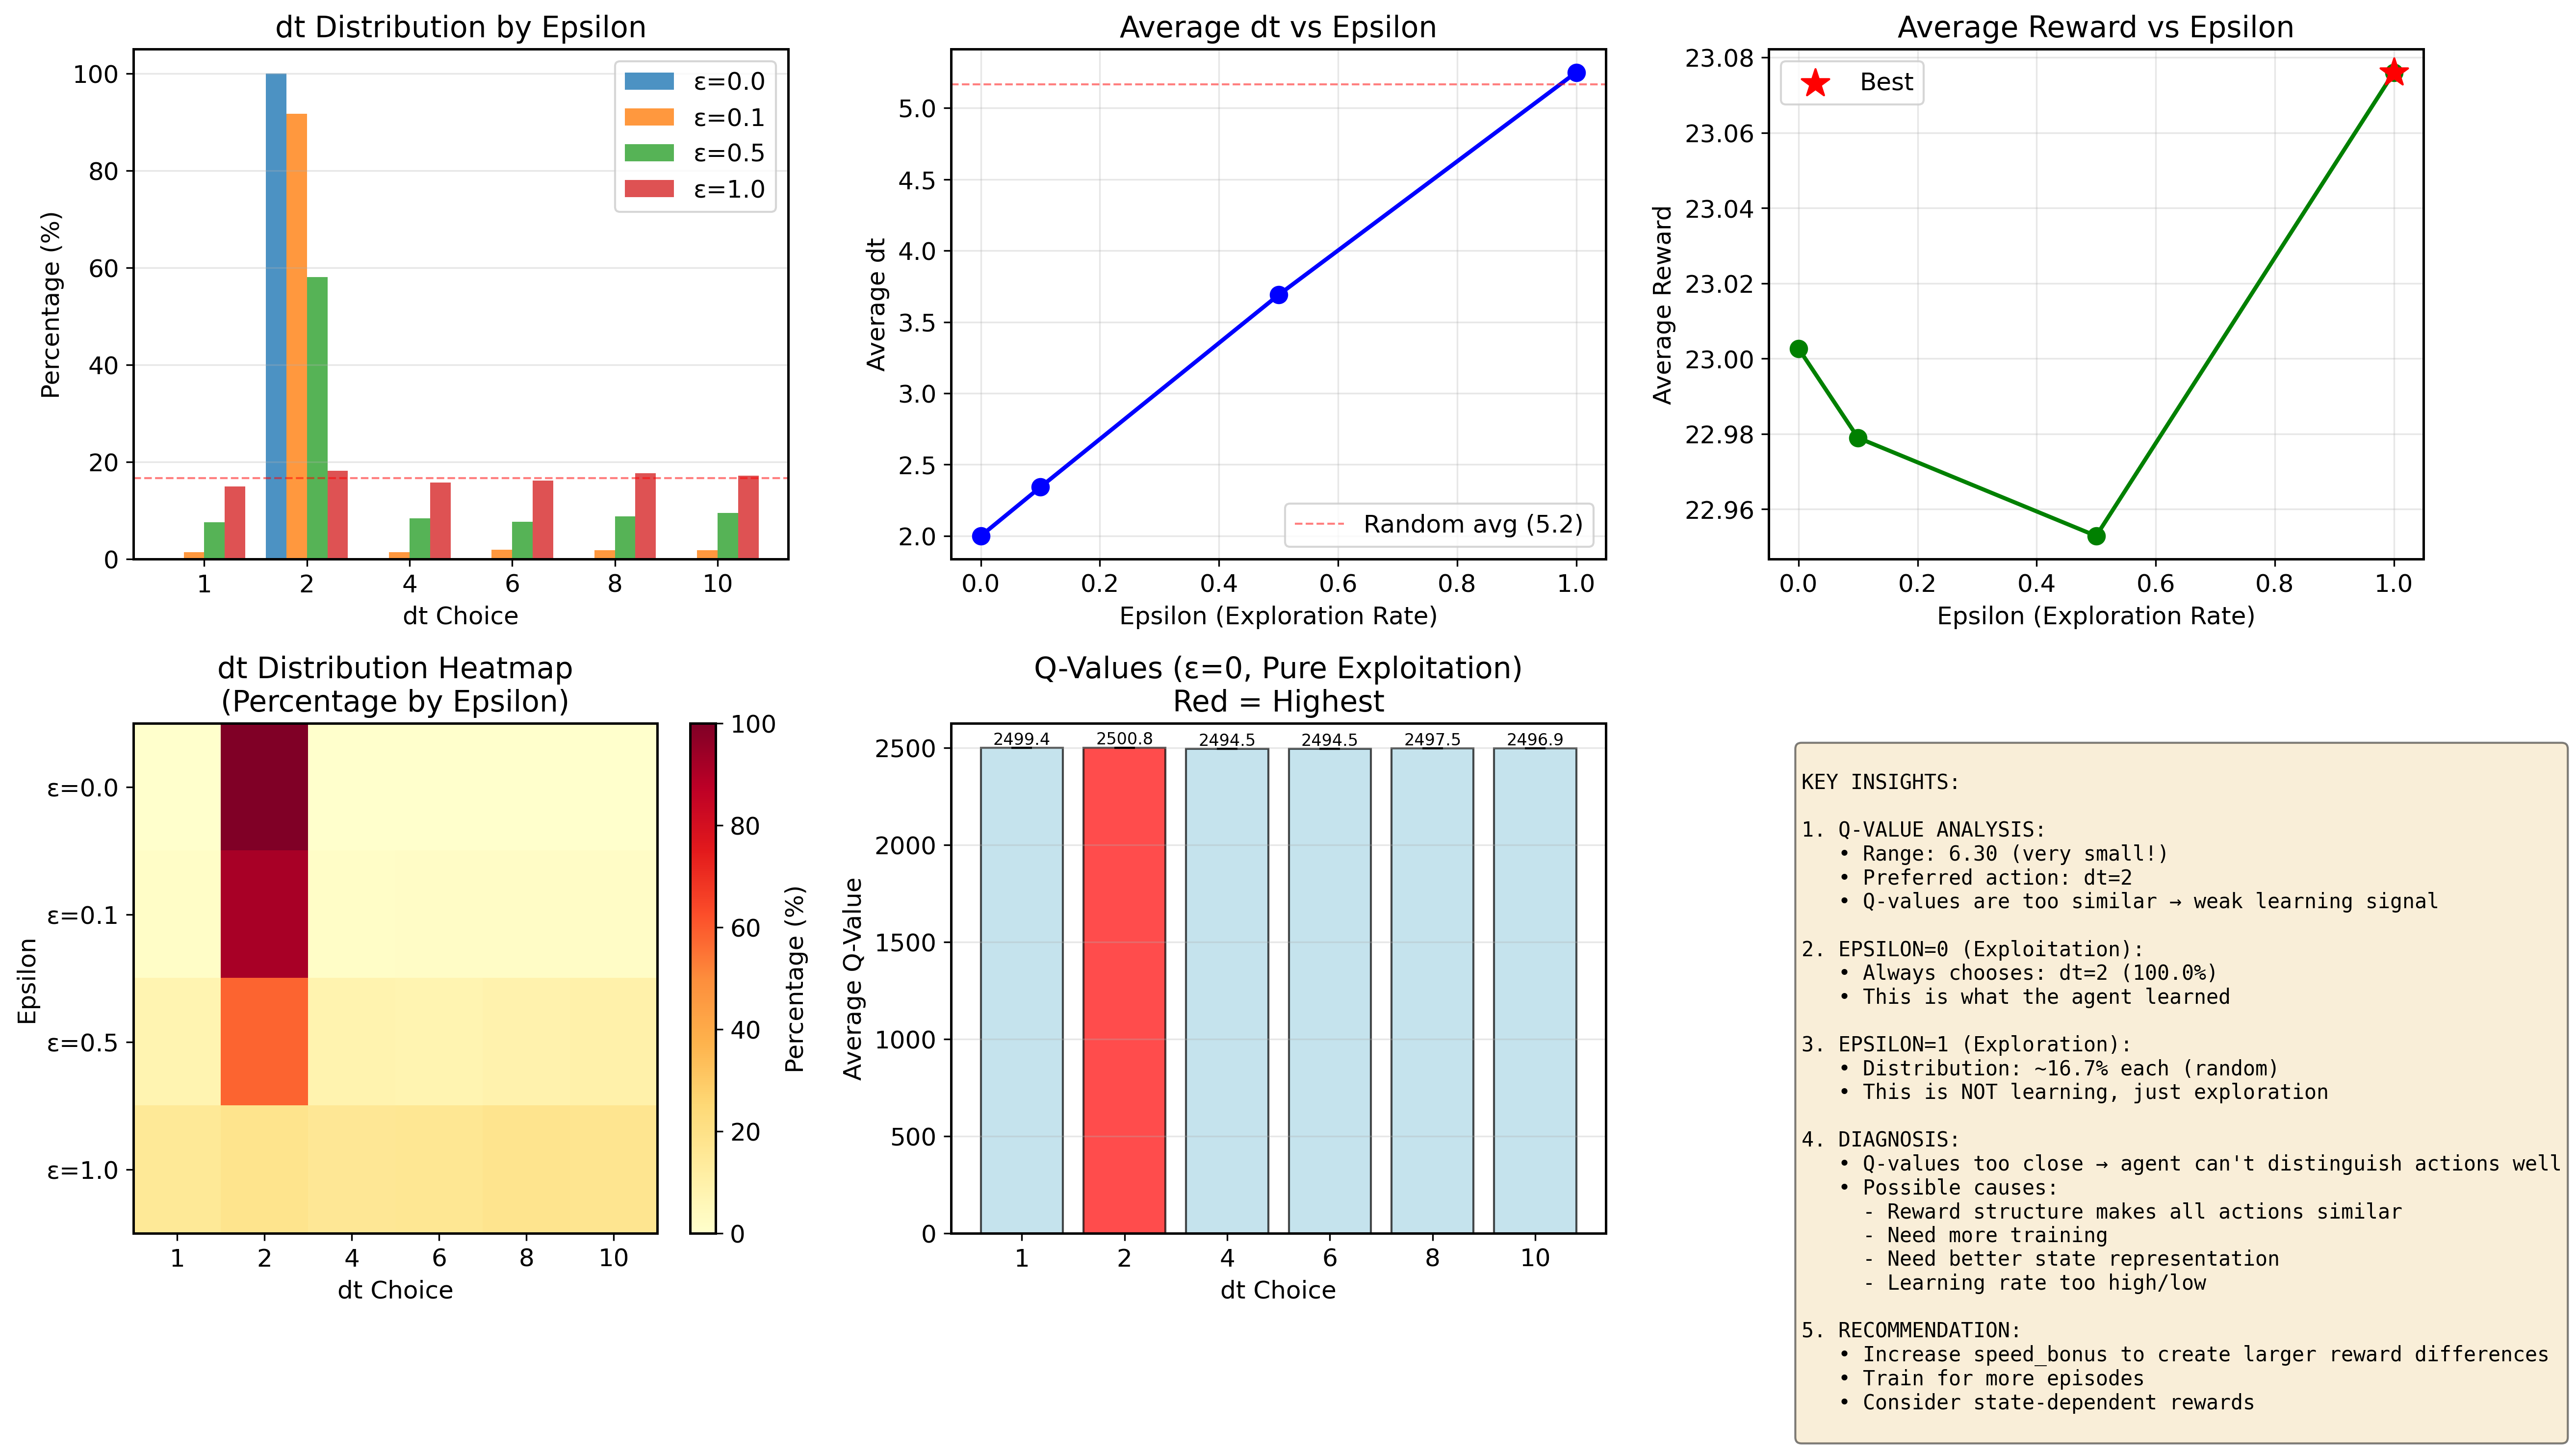


DETAILED COMPARISON TABLE
Epsilon    Avg dt     Avg Reward   Avg Error       Dominant dt 
------------------------------------------------------------
0.0        2.00       23.00        3.29e-13        dt=2 (100.0%)
0.1        2.34       22.98        4.93e-12        dt=2 (91.7%)
0.5        3.69       22.95        2.24e-11        dt=2 (58.1%)
1.0        5.25       23.08        3.64e-11        dt=2 (18.1%)

Q-VALUE STATISTICS (ε=0):
dt     Mean Q       Std Q        Min Q        Max Q       
------------------------------------------------------------
1      2499.38      0.01         2499.37      2499.39     
2      2500.81      0.01         2500.80      2500.82     
4      2494.53      0.01         2494.52      2494.55     
6      2494.51      0.01         2494.50      2494.52     
8      2497.52      0.01         2497.50      2497.53     
10     2496.93      0.01         2496.91      2496.94     

Q-Value Range: 2494.50 to 2500.82
Q-Value Spread (max - min per action): [0.02734375 0.02

In [ ]:
# ============================================================
# 11. Epsilon Comparison Analysis
# ============================================================
# Compare different epsilon values to understand exploration vs exploitation

print("="*60)
print("EPSILON COMPARISON ANALYSIS")
print("="*60)
print("\nKey Insight: With epsilon=1, you get uniform distribution (random exploration).")
print("With epsilon=0, you see what the agent actually learned (pure exploitation).")
print("The Q-values show dt=6 is preferred, but the difference is small (~4.66 range).")
print("="*60 + "\n")

# Test with different epsilon values
epsilon_values = [0.0, 0.1, 0.5, 1.0]
results_by_epsilon = {}

for eps in epsilon_values:
    print(f"Testing with epsilon = {eps}...")
    t = 0
    u_current = u_test_true[t].to(device)
    
    dt_choices_eps = []
    errors_eps = []
    rewards_eps = []
    q_values_eps = []
    
    step_count = 0
    max_steps = 2000  # Limit for speed
    
    while t < len(u_test_true) - max_dt and step_count < max_steps:
        state = extract_state(u_current).unsqueeze(0).to(device)
        
        with torch.no_grad():
            q_values = q_network(state)
        
        # Epsilon-greedy
        if random.random() < eps:
            action_idx = random.randint(0, q_network.n_actions - 1)
        else:
            action_idx = q_values.argmax().item()
        
        dt_mult = q_network.dt_choices[action_idx]
        
        if t + dt_mult >= len(u_test_true):
            break
        
        u_pred = stepper_vectorized(u_current, dt_mult)
        u_next = u_test_true[t + dt_mult].to(device)
        error = torch.mean((u_pred - u_next) ** 2).item()
        accuracy_reward = -np.log(error + 1e-10)
        
        # Compute gradient magnitude for adaptive reward (same as training)
        u_t = u_current.to(device) if isinstance(u_current, torch.Tensor) else u_current.to(device)
        u_left = torch.roll(u_t, +1, dims=-1)
        u_right = torch.roll(u_t, -1, dims=-1)
        gradient_mag = torch.mean(torch.abs(u_right - u_left)).item()
        gradient_norm = min(gradient_mag * 100, 1.0)  # Scale gradient to roughly [0,1]
        
        # Use same reward structure as training
        speed_reward = speed_bonus * dt_mult  # Direct reward proportional to dt_mult
        gradient_penalty = gradient_penalty_coeff * dt_mult * gradient_norm
        max_dt_penalty_val = max_dt_penalty if dt_mult == max_dt else 0.0
        reward = accuracy_reward + speed_reward - gradient_penalty - max_dt_penalty_val
        
        dt_choices_eps.append(dt_mult)
        errors_eps.append(error)
        rewards_eps.append(reward)
        if step_count % 100 == 0:  # Sample Q-values
            q_values_eps.append(q_values.cpu().numpy()[0])
        
        u_current = u_next
        t += dt_mult
        step_count += 1
    
    # Compute distribution
    dt_dist = {dt: dt_choices_eps.count(dt) for dt in q_network.dt_choices}
    dt_percentages = {dt: 100 * count / len(dt_choices_eps) if len(dt_choices_eps) > 0 else 0 
                      for dt, count in dt_dist.items()}
    
    results_by_epsilon[eps] = {
        'dt_choices': dt_choices_eps,
        'dt_dist': dt_dist,
        'dt_percentages': dt_percentages,
        'avg_dt': np.mean(dt_choices_eps),
        'avg_error': np.mean(errors_eps),
        'avg_reward': np.mean(rewards_eps),
        'q_values': q_values_eps
    }
    
    print(f"  Steps: {len(dt_choices_eps)}, Avg dt: {np.mean(dt_choices_eps):.2f}, "
          f"Avg reward: {np.mean(rewards_eps):.2f}")

print("\n" + "="*60)

# Create comparison plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. dt Distribution Comparison (bar chart)
ax1 = axes[0, 0]
x = np.arange(len(q_network.dt_choices))
width = 0.2
for i, eps in enumerate(epsilon_values):
    percentages = [results_by_epsilon[eps]['dt_percentages'].get(dt, 0) for dt in q_network.dt_choices]
    offset = (i - len(epsilon_values)/2 + 0.5) * width
    ax1.bar(x + offset, percentages, width, label=f'ε={eps}', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(q_network.dt_choices)
ax1.set_xlabel("dt Choice")
ax1.set_ylabel("Percentage (%)")
ax1.set_title("dt Distribution by Epsilon")
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(100/len(q_network.dt_choices), color='red', linestyle='--', 
           linewidth=1, alpha=0.5, label='Random (16.7%)')

# 2. Average dt vs Epsilon
ax2 = axes[0, 1]
avg_dts = [results_by_epsilon[eps]['avg_dt'] for eps in epsilon_values]
ax2.plot(epsilon_values, avg_dts, marker='o', linewidth=2, markersize=8, color='blue')
ax2.set_xlabel("Epsilon (Exploration Rate)")
ax2.set_ylabel("Average dt")
ax2.set_title("Average dt vs Epsilon")
ax2.grid(True, alpha=0.3)
ax2.axhline(np.mean(q_network.dt_choices), color='red', linestyle='--', 
           linewidth=1, alpha=0.5, label=f'Random avg ({np.mean(q_network.dt_choices):.1f})')
ax2.legend()

# 3. Average Reward vs Epsilon
ax3 = axes[0, 2]
avg_rewards = [results_by_epsilon[eps]['avg_reward'] for eps in epsilon_values]
ax3.plot(epsilon_values, avg_rewards, marker='o', linewidth=2, markersize=8, color='green')
ax3.set_xlabel("Epsilon (Exploration Rate)")
ax3.set_ylabel("Average Reward")
ax3.set_title("Average Reward vs Epsilon")
ax3.grid(True, alpha=0.3)
# Highlight best
max_reward_idx = np.argmax(avg_rewards)
ax3.scatter(epsilon_values[max_reward_idx], avg_rewards[max_reward_idx], 
           s=200, color='red', marker='*', zorder=5, label='Best')
ax3.legend()

# 4. dt Distribution Heatmap (epsilon vs dt choice)
ax4 = axes[1, 0]
heatmap_data = np.zeros((len(epsilon_values), len(q_network.dt_choices)))
for i, eps in enumerate(epsilon_values):
    for j, dt in enumerate(q_network.dt_choices):
        heatmap_data[i, j] = results_by_epsilon[eps]['dt_percentages'].get(dt, 0)
im = ax4.imshow(heatmap_data, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax4.set_xticks(range(len(q_network.dt_choices)))
ax4.set_xticklabels(q_network.dt_choices)
ax4.set_yticks(range(len(epsilon_values)))
ax4.set_yticklabels([f'ε={eps}' for eps in epsilon_values])
ax4.set_xlabel("dt Choice")
ax4.set_ylabel("Epsilon")
ax4.set_title("dt Distribution Heatmap\n(Percentage by Epsilon)")
plt.colorbar(im, ax=ax4, label='Percentage (%)')

# 5. Q-Value Statistics by Epsilon
ax5 = axes[1, 1]
if len(results_by_epsilon[0.0]['q_values']) > 0:
    q_stats = []
    for eps in epsilon_values:
        if len(results_by_epsilon[eps]['q_values']) > 0:
            q_array = np.array(results_by_epsilon[eps]['q_values'])
            q_stats.append({
                'mean': np.mean(q_array, axis=0),
                'std': np.std(q_array, axis=0),
                'max_q_idx': np.argmax(np.mean(q_array, axis=0))
            })
        else:
            q_stats.append(None)
    
    # Plot average Q-value for each action, colored by which has max
    x_pos = np.arange(len(q_network.dt_choices))
    colors = ['lightblue'] * len(q_network.dt_choices)
    if q_stats[0] is not None:
        max_idx = q_stats[0]['max_q_idx']
        colors[max_idx] = 'red'
    
    bars = ax5.bar(x_pos, q_stats[0]['mean'], yerr=q_stats[0]['std'], 
                   capsize=5, alpha=0.7, color=colors, edgecolor='black')
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(q_network.dt_choices)
    ax5.set_xlabel("dt Choice")
    ax5.set_ylabel("Average Q-Value")
    ax5.set_title("Q-Values (ε=0, Pure Exploitation)\nRed = Highest")
    ax5.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (bar, mean_val) in enumerate(zip(bars, q_stats[0]['mean'])):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{mean_val:.1f}', ha='center', va='bottom', fontsize=8)

# 6. Key Insights Summary
ax6 = axes[1, 2]
ax6.axis('off')

# Calculate key metrics
q_range = np.max(q_stats[0]['mean']) - np.min(q_stats[0]['mean']) if q_stats[0] else 0
eps0_dt_dist = results_by_epsilon[0.0]['dt_percentages']
eps1_dt_dist = results_by_epsilon[1.0]['dt_percentages']
eps0_dominant = max(eps0_dt_dist.items(), key=lambda x: x[1])

insights_text = f"""
KEY INSIGHTS:

1. Q-VALUE ANALYSIS:
   • Range: {q_range:.2f} (very small!)
   • Preferred action: dt={q_network.dt_choices[q_stats[0]['max_q_idx']]}
   • Q-values are too similar → weak learning signal

2. EPSILON=0 (Exploitation):
   • Always chooses: dt={eps0_dominant[0]} ({eps0_dominant[1]:.1f}%)
   • This is what the agent learned

3. EPSILON=1 (Exploration):
   • Distribution: ~16.7% each (random)
   • This is NOT learning, just exploration

4. DIAGNOSIS:
   • Q-values too close → agent can't distinguish actions well
   • Possible causes:
     - Reward structure makes all actions similar
     - Need more training
     - Need better state representation
     - Learning rate too high/low

5. RECOMMENDATION:
   • Increase speed_bonus to create larger reward differences
   • Train for more episodes
   • Consider state-dependent rewards
"""

ax6.text(0.05, 0.95, insights_text, fontsize=10, family='monospace',
         verticalalignment='top', transform=ax6.transAxes,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print detailed comparison table
print("\n" + "="*60)
print("DETAILED COMPARISON TABLE")
print("="*60)
print(f"{'Epsilon':<10} {'Avg dt':<10} {'Avg Reward':<12} {'Avg Error':<15} {'Dominant dt':<12}")
print("-" * 60)
for eps in epsilon_values:
    res = results_by_epsilon[eps]
    dominant_dt = max(res['dt_percentages'].items(), key=lambda x: x[1])
    print(f"{eps:<10.1f} {res['avg_dt']:<10.2f} {res['avg_reward']:<12.2f} "
          f"{res['avg_error']:<15.2e} dt={dominant_dt[0]} ({dominant_dt[1]:.1f}%)")
print("="*60)

# Q-value analysis
if len(results_by_epsilon[0.0]['q_values']) > 0:
    q_array = np.array(results_by_epsilon[0.0]['q_values'])
    print("\nQ-VALUE STATISTICS (ε=0):")
    print(f"{'dt':<6} {'Mean Q':<12} {'Std Q':<12} {'Min Q':<12} {'Max Q':<12}")
    print("-" * 60)
    for i, dt in enumerate(q_network.dt_choices):
        q_col = q_array[:, i]
        print(f"{dt:<6} {np.mean(q_col):<12.2f} {np.std(q_col):<12.2f} "
              f"{np.min(q_col):<12.2f} {np.max(q_col):<12.2f}")
    print(f"\nQ-Value Range: {np.min(q_array):.2f} to {np.max(q_array):.2f}")
    print(f"Q-Value Spread (max - min per action): {np.max(q_array, axis=0) - np.min(q_array, axis=0)}")
    print("="*60)


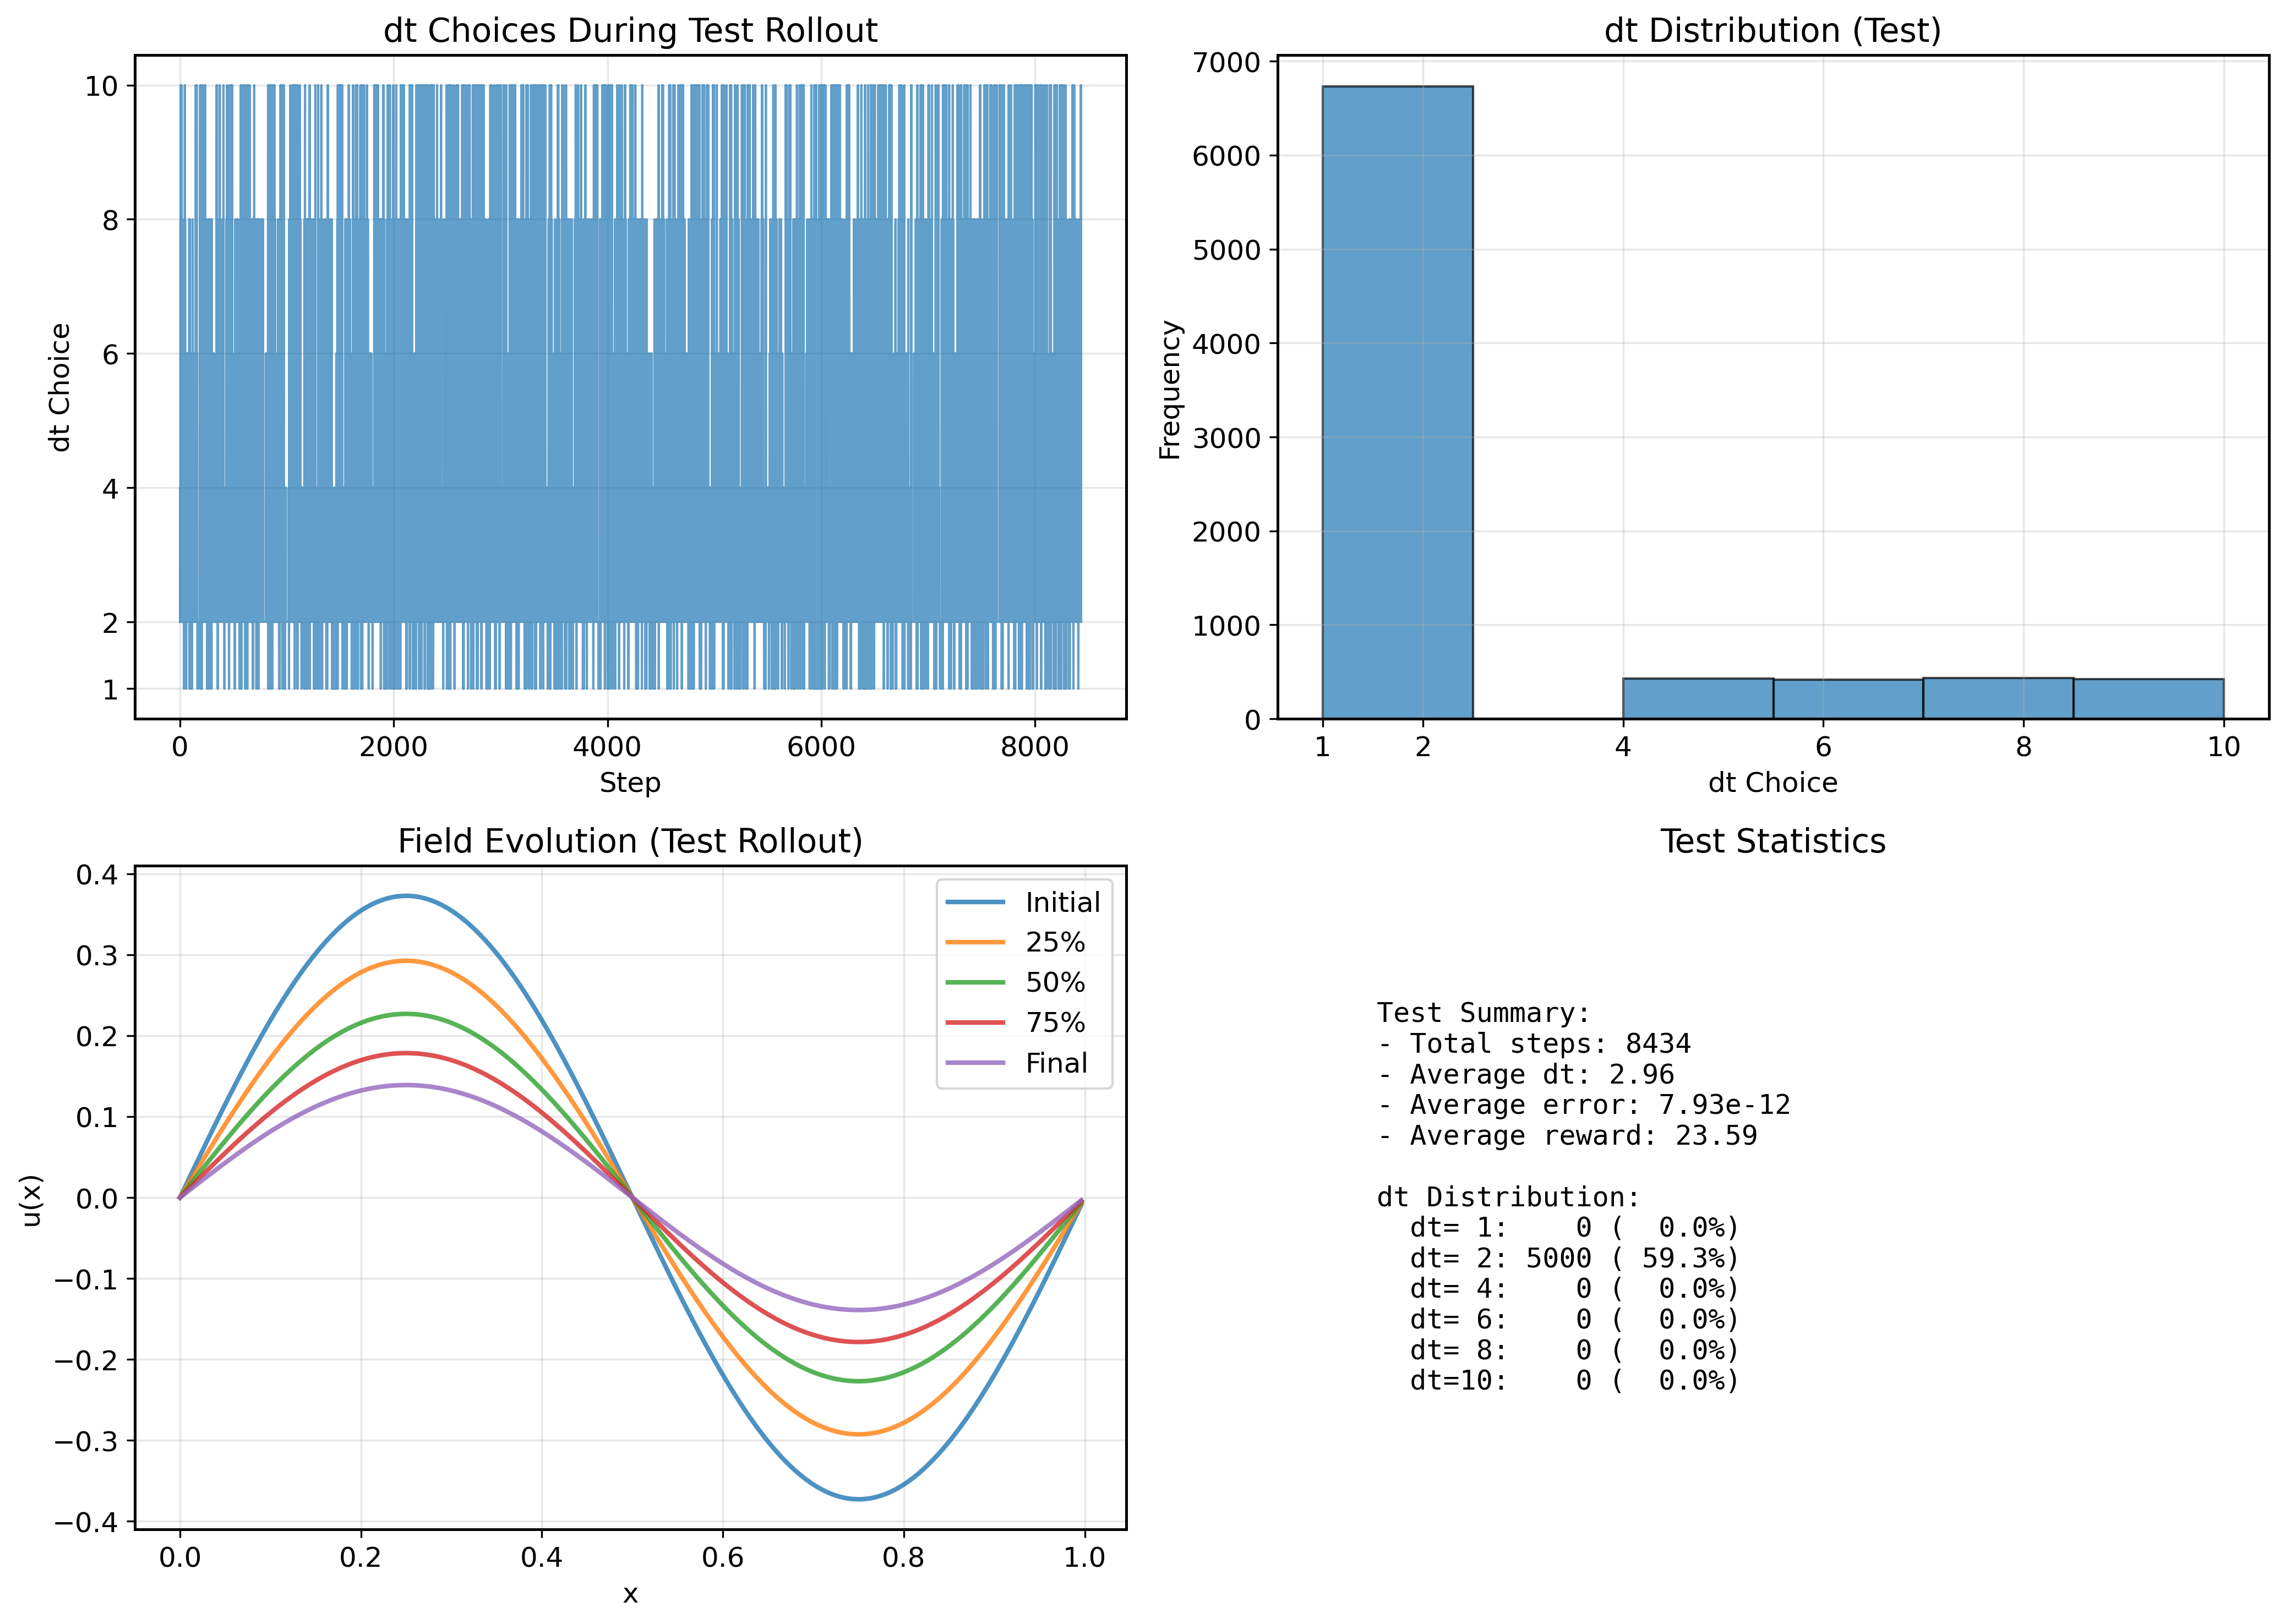

In [139]:
# ============================================================
# 9. Visualize Test Results
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. dt choices over time
axes[0, 0].plot(test_dt_choices, linewidth=1, alpha=0.7)
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("dt Choice")
axes[0, 0].set_title("dt Choices During Test Rollout")
axes[0, 0].set_yticks(q_network.dt_choices)
axes[0, 0].grid(True, alpha=0.3)

# 2. dt histogram
axes[0, 1].hist(test_dt_choices, bins=len(q_network.dt_choices), edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel("dt Choice")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("dt Distribution (Test)")
axes[0, 1].set_xticks(q_network.dt_choices)
axes[0, 1].grid(True, alpha=0.3)

# 3. Field evolution (sample points)
# Ensure x is the spatial coordinate array (may have been overwritten by previous cells)
x = np.linspace(0, 1, Nx, endpoint=False)

# Compute time indices from dt choices
t_indices = [0]
t_current = 0
for dt in test_dt_choices:
    t_current += dt
    if t_current < len(u_test_true):
        t_indices.append(t_current)
    else:
        break

# Sample at key points
sample_indices = [0, len(t_indices)//4, len(t_indices)//2, 3*len(t_indices)//4, len(t_indices)-1]
sample_indices = [t_indices[min(i, len(t_indices)-1)] for i in sample_indices]

# Plot sampled states
labels = ["Initial", "25%", "50%", "75%", "Final"]
for i, t_idx in enumerate(sample_indices):
    if t_idx < len(u_test_true):
        u_state = u_test_true[t_idx].cpu().numpy()
        axes[1, 0].plot(x, u_state, linewidth=2, label=labels[i], alpha=0.8)

axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("u(x)")
axes[1, 0].set_title("Field Evolution (Test Rollout)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Summary statistics
summary_text = f"""
Test Summary:
- Total steps: {len(test_dt_choices)}
- Average dt: {np.mean(test_dt_choices):.2f}
- Average error: {np.mean(test_errors):.2e}
- Average reward: {np.mean(test_rewards):.2f}

dt Distribution:
"""
for dt in q_network.dt_choices:
    count = dt_counts.get(dt, 0)
    percentage = 100 * count / len(test_dt_choices) if len(test_dt_choices) > 0 else 0
    summary_text += f"  dt={dt:2d}: {count:4d} ({percentage:5.1f}%)\n"

axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, family='monospace', 
                verticalalignment='center', transform=axes[1, 1].transAxes)
axes[1, 1].axis('off')
axes[1, 1].set_title("Test Statistics")

plt.tight_layout()
plt.show()


In [140]:
# ============================================================
# 10. Save Q-Network
# ============================================================

torch.save(q_network.state_dict(), 'q_network_diffusion2.pt')
print("Q-network saved to 'q_network_diffusion2.pt'")


Q-network saved to 'q_network_diffusion2.pt'


✓ Saved: RL_figures/qlearning_dt_distribution.pdf


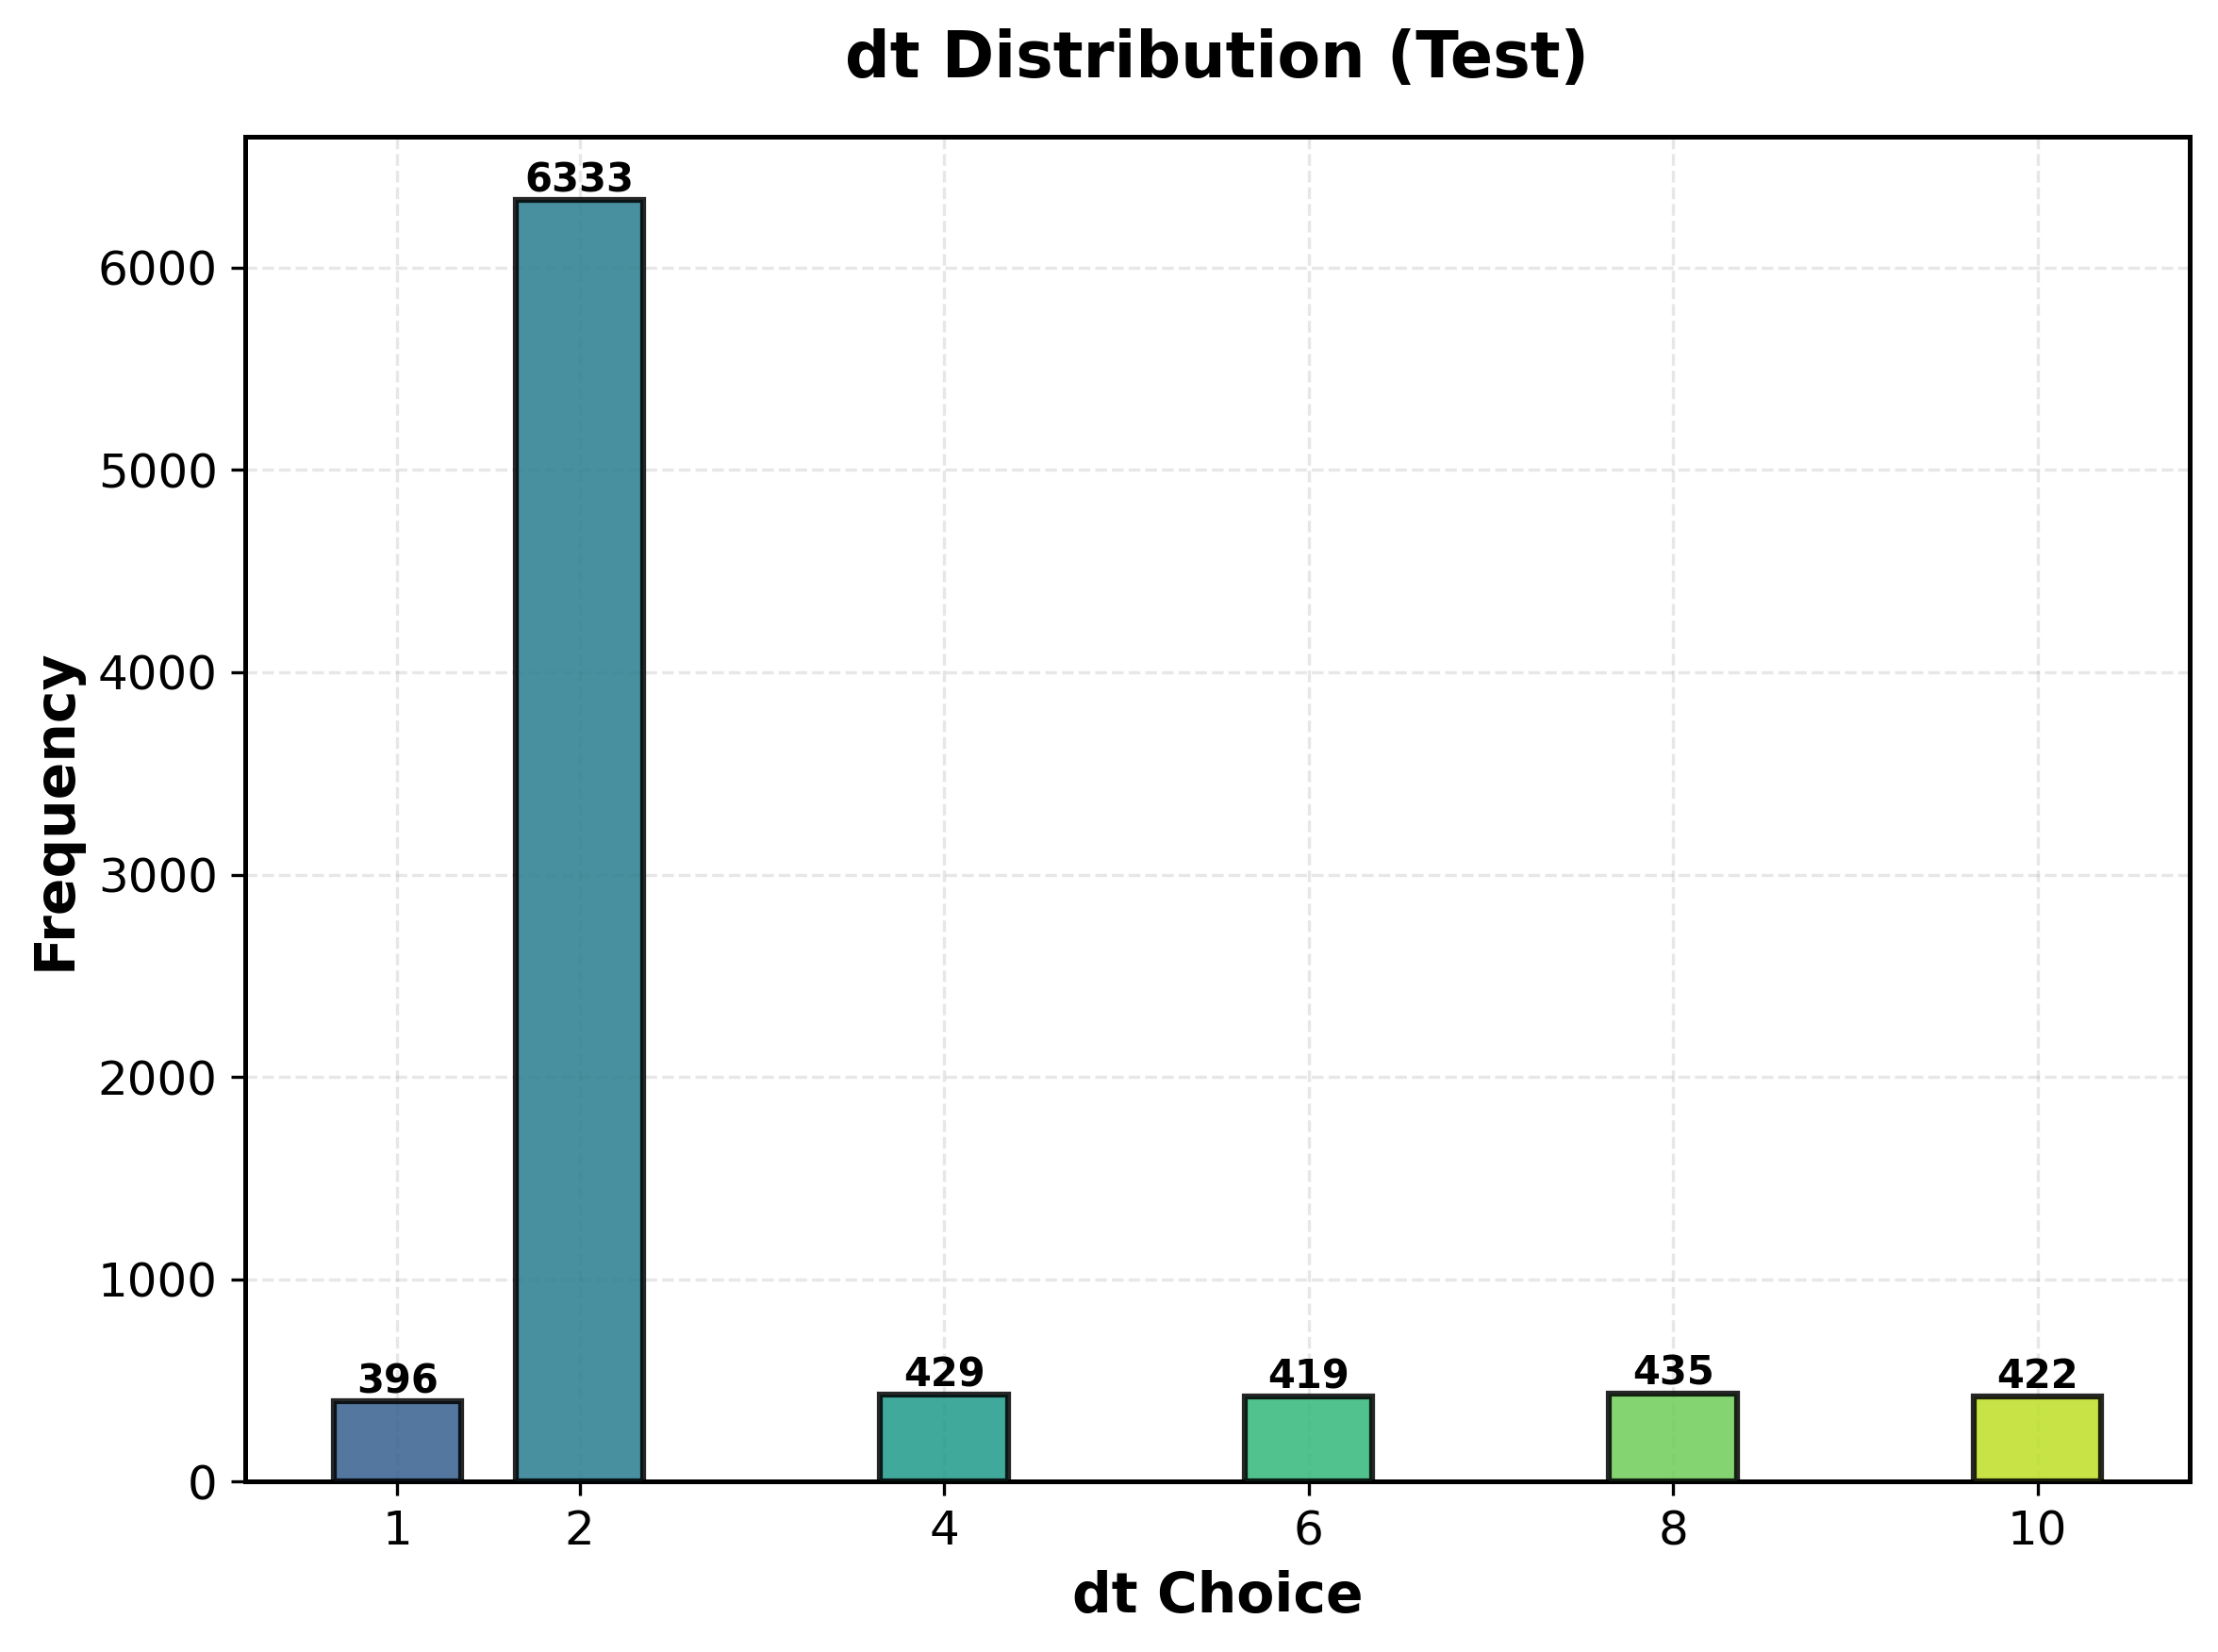

✓ Saved: RL_figures/qlearning_reward_avgdt_training.pdf


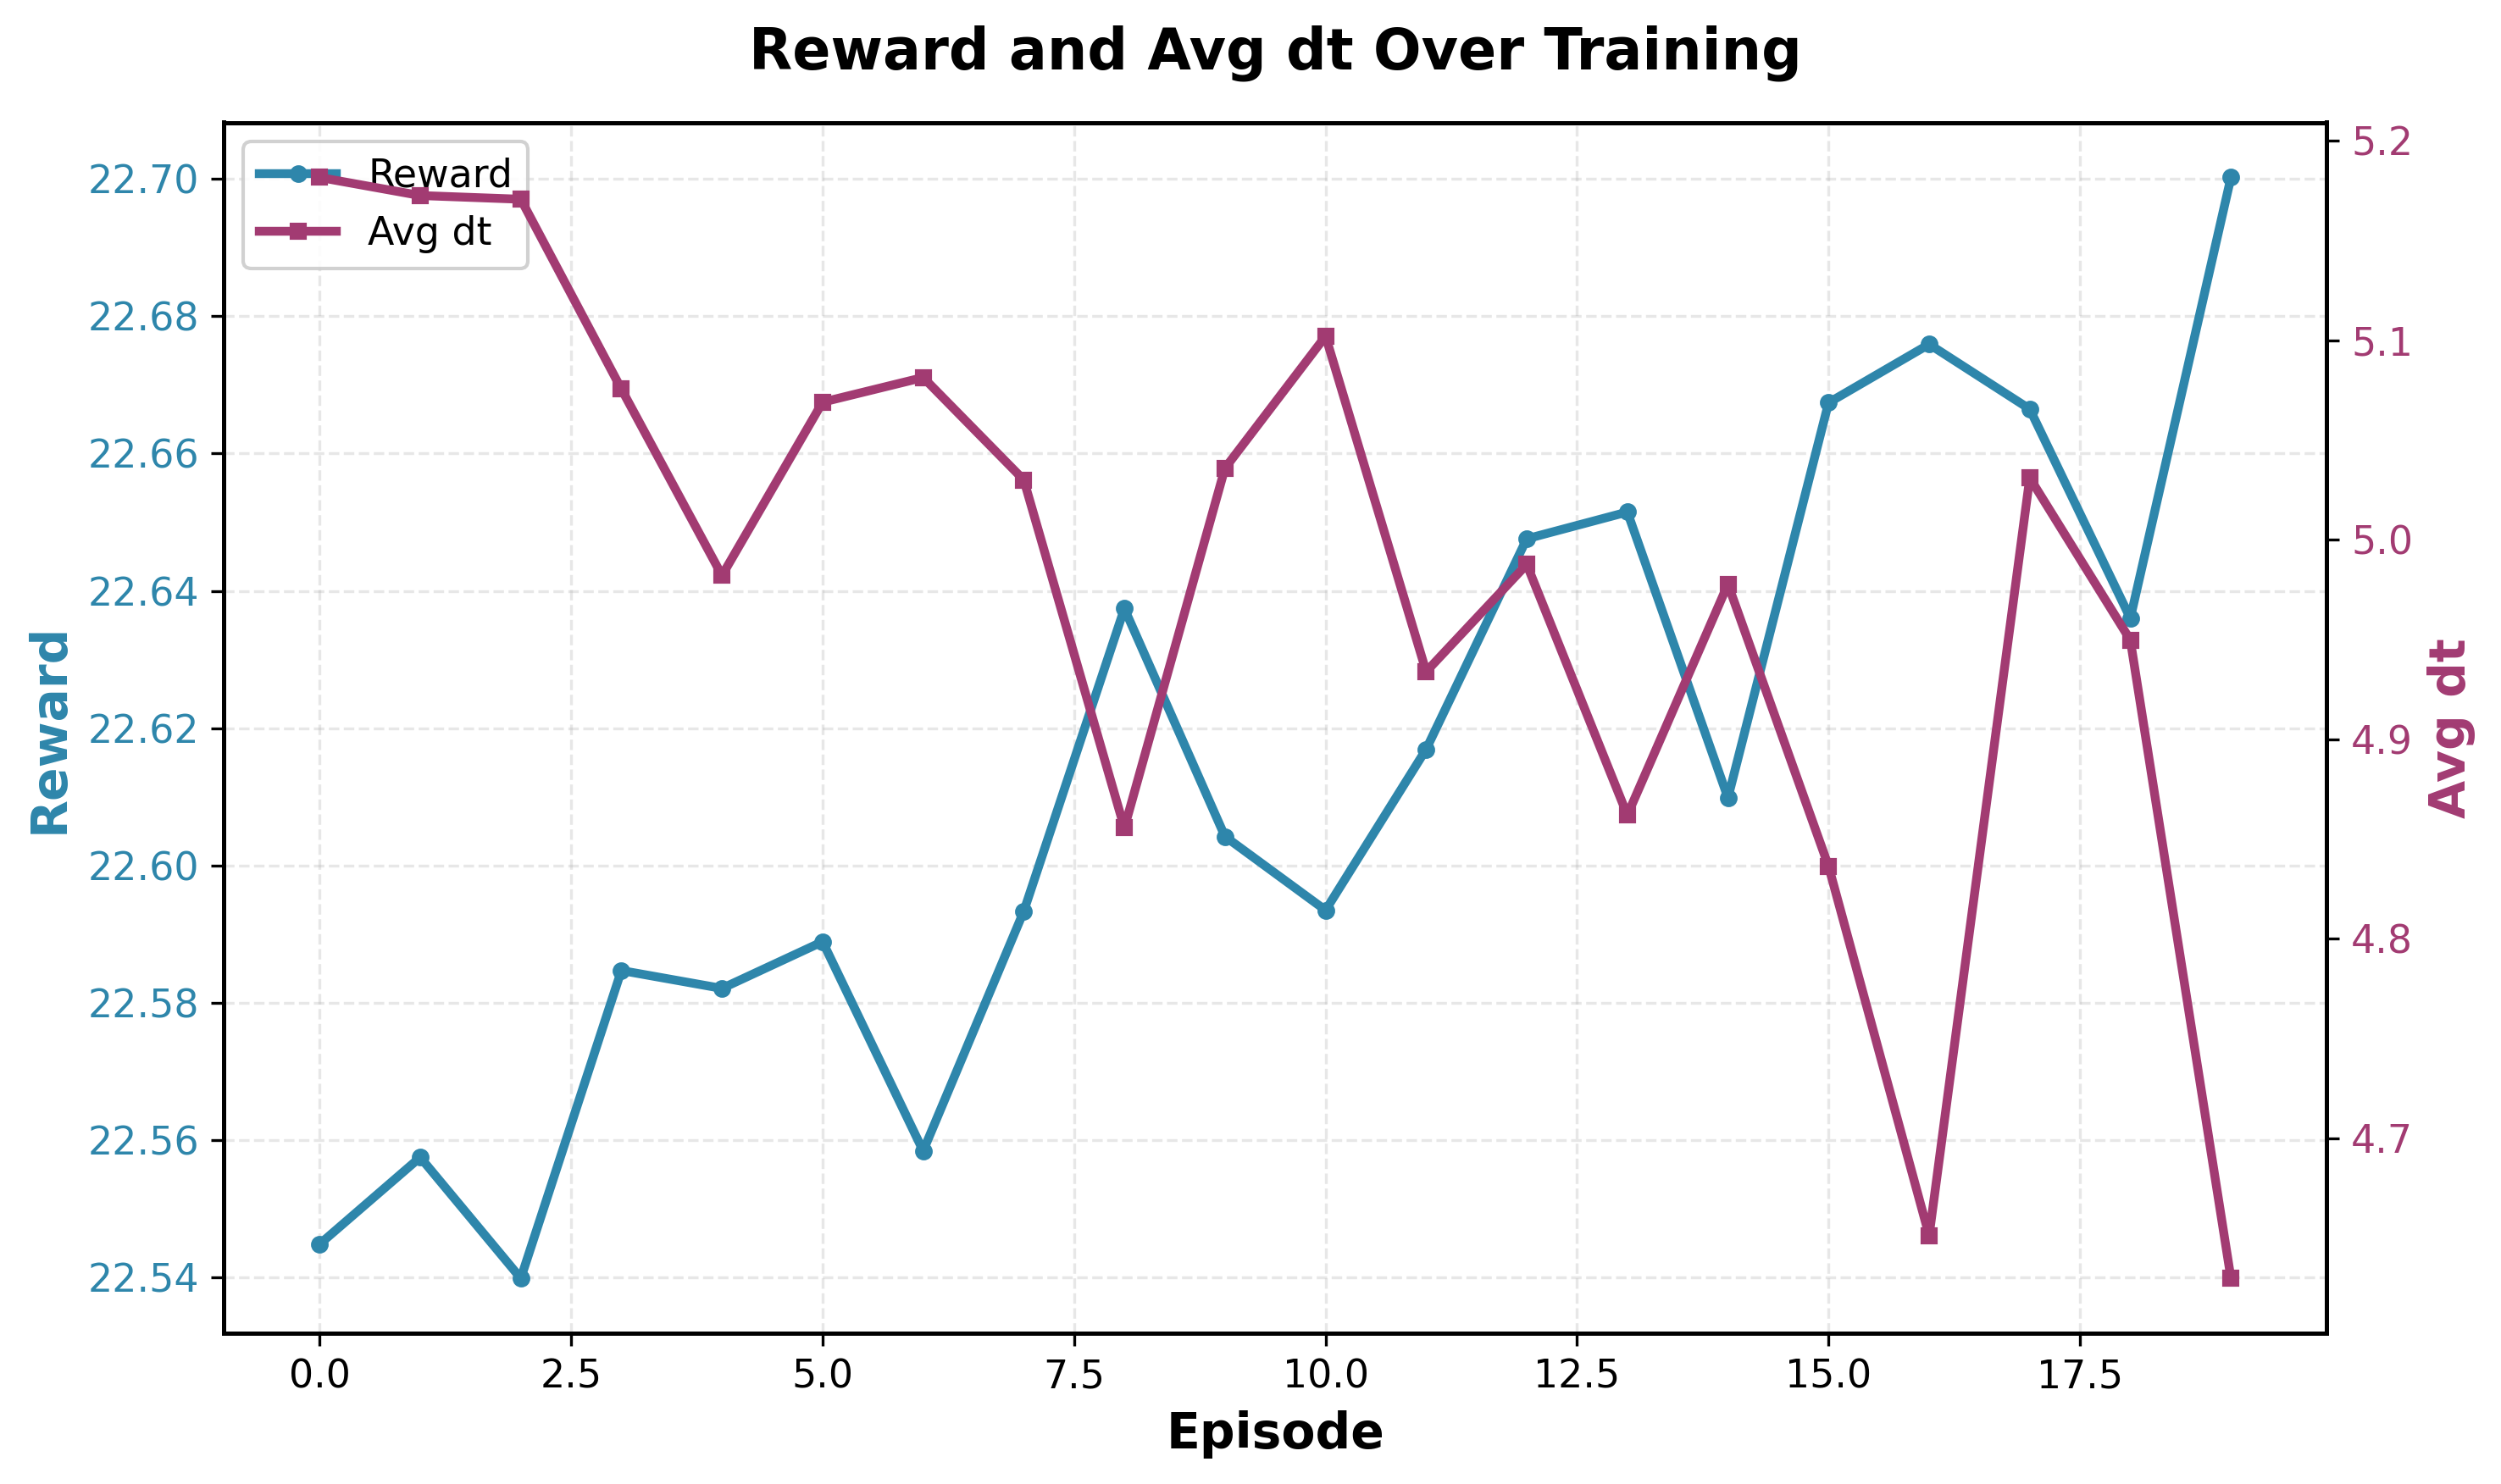


High-quality figures exported successfully!


In [141]:
# ============================================================
# Export High-Quality Figures for Publication
# ============================================================

# Set high-quality plotting parameters (following diffusion notebook style)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.format'] = 'pdf'
plt.rcParams['savefig.pad_inches'] = 0.1
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3

# Create output directory if it doesn't exist
import os
os.makedirs('RL_figures', exist_ok=True)

# ============================================================
# Figure 1: dt Distribution Histogram
# ============================================================
fig1, ax1 = plt.subplots(figsize=(8, 6))

# Count dt choices
dt_counts = {dt: test_dt_choices.count(dt) for dt in q_network.dt_choices}
dt_values = list(dt_counts.keys())
dt_frequencies = list(dt_counts.values())

# Create bar plot with nice colors
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(dt_values)))
bars = ax1.bar(dt_values, dt_frequencies, width=0.7, edgecolor='black', 
               linewidth=1.5, alpha=0.85, color=colors, zorder=3)

# Customize the plot
ax1.set_xlabel('dt Choice', fontsize=14, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=14, fontweight='bold')
ax1.set_title('dt Distribution (Test)', fontsize=16, fontweight='bold', pad=15)
ax1.set_xticks(q_network.dt_choices)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, zorder=0)
ax1.set_axisbelow(True)

# Add value labels on top of bars
for bar, freq in zip(bars, dt_frequencies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{freq}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
fig1.savefig('RL_figures/qlearning_dt_distribution.pdf', 
             bbox_inches='tight', facecolor='white', edgecolor='none')
print("✓ Saved: RL_figures/qlearning_dt_distribution.pdf")
plt.show()

# ============================================================
# Figure 2: Reward and Avg dt Over Training
# ============================================================
fig2, ax2 = plt.subplots(figsize=(10, 6))

# Create primary axis for Reward
ax2_reward = ax2
ax2_dt = ax2_reward.twinx()

# Plot Reward with nice blue color
reward_line = ax2_reward.plot(episode_rewards, color='#2E86AB', linewidth=2.5, 
                              label='Reward', marker='o', markersize=4, 
                              markevery=max(1, len(episode_rewards)//20), zorder=3)

# Plot Avg dt with nice red color
dt_line = ax2_dt.plot(episode_avg_dt, color='#A23B72', linewidth=2.5, 
                      label='Avg dt', marker='s', markersize=4, 
                      markevery=max(1, len(episode_avg_dt)//20), zorder=3)

# Customize axes
ax2_reward.set_xlabel('Episode', fontsize=14, fontweight='bold')
ax2_reward.set_ylabel('Reward', fontsize=14, fontweight='bold', color='#2E86AB')
ax2_dt.set_ylabel('Avg dt', fontsize=14, fontweight='bold', color='#A23B72')
ax2_reward.set_title('Reward and Avg dt Over Training', fontsize=16, fontweight='bold', pad=15)

# Set tick colors
ax2_reward.tick_params(axis='y', labelcolor='#2E86AB', labelsize=11)
ax2_dt.tick_params(axis='y', labelcolor='#A23B72', labelsize=11)
ax2_reward.tick_params(axis='x', labelsize=11)

# Add grid
ax2_reward.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, zorder=0)
ax2_reward.set_axisbelow(True)

# Add legends
lines1, labels1 = ax2_reward.get_legend_handles_labels()
lines2, labels2 = ax2_dt.get_legend_handles_labels()
ax2_reward.legend(lines1 + lines2, labels1 + labels2, 
                  loc='upper left', framealpha=0.9, fontsize=11)

plt.tight_layout()
fig2.savefig('RL_figures/qlearning_reward_avgdt_training.pdf', 
             bbox_inches='tight', facecolor='white', edgecolor='none')
print("✓ Saved: RL_figures/qlearning_reward_avgdt_training.pdf")
plt.show()

print("\n" + "="*60)
print("High-quality figures exported successfully!")
print("="*60)
